# Baseline CNN Model 

* __Libraries/Modules__

In [4]:
from pathlib import Path
import sys

PROJECT_ROOT = Path("..").resolve()
SRC_DIR = PROJECT_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

In [2]:
import torch
import pandas as pd
import matplotlib.pyplot as plt
import cv2

from torch.utils.data import DataLoader

from anpr.data.dataset import PlateDataset
from anpr.data.transforms import get_train_transforms, get_eval_transforms, get_stress_test_transforms
from anpr.models.plate_cnn import PlateCNN, count_trainable_parameters
from anpr.training.losses import PlateMultiHeadLoss
from anpr.training.train_loop import train_one_epoch, evaluate_one_epoch
from anpr.evaluation.metrics import format_plate_metrics
from anpr.inference.decode import decode_model_outputs
from anpr.inference.predict import PlateRecognizer

c:\Users\kosko\OneDrive\Python\machine_learning\Projects\Car-Parking\.ml_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


* __Loading CPU/GPU Device for PyTorch__

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

* __Declare Constants__

In [4]:
batch_size = 64
num_epochs = 10
lr = 1e-3
weight_decay = 1e-4
dropout = 0.1
pooled_width = 10

METADATA_CSV = PROJECT_ROOT / "data" / "metadata" / "plates.csv"

* __Declare Transformers__

In [5]:
transform = get_eval_transforms(
    image_height=48,
    image_width=160,
)

train_ds = PlateDataset(
    metadata=METADATA_CSV,
    project_root=PROJECT_ROOT,
    split="train",
    transform=transform,
    grayscale=True,
)

val_ds = PlateDataset(
    metadata=METADATA_CSV,
    project_root=PROJECT_ROOT,
    split="val",
    transform=transform,
    grayscale=True,
)

test_ds = PlateDataset(
    metadata=METADATA_CSV,
    project_root=PROJECT_ROOT,
    split="test",
    transform=transform,
    grayscale=True,
)

len(train_ds), len(val_ds), len(test_ds)

(19200, 2400, 2400)

* __Declare Data Loaders__

In [13]:
batch_size = 64

train_loader = DataLoader(
    train_ds,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

val_loader = DataLoader(
    val_ds,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

test_loader = DataLoader(
    test_ds,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

* __Declare CNN Model with Hyperparameters__

In [7]:
model = PlateCNN(
    in_channels=1,
    dropout=0.1,
    pooled_width=10,
).to(device)

loss_fn = PlateMultiHeadLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4,
)

print("Trainable parameters:", count_trainable_parameters(model))

Trainable parameters: 772470


* __Train Model on Train Data__

In [8]:
CHECKPOINT_DIR = PROJECT_ROOT / "checkpoints" / "baseline_cnn"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_DIR = PROJECT_ROOT / "outputs" / "predictions"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

best_val_accuracy = 0.0
best_checkpoint_path = CHECKPOINT_DIR / "plate_cnn_baseline_best.pt"

num_epochs = 3
history = []

for epoch in range(1, num_epochs + 1):
    train_result = train_one_epoch(
        model=model,
        dataloader=train_loader,
        loss_fn=loss_fn,
        optimizer=optimizer,
        device=device,
        show_progress=True,
    )

    val_result = evaluate_one_epoch(
        model=model,
        dataloader=val_loader,
        loss_fn=loss_fn,
        device=device,
        show_progress=True,
    )

    val_metrics = val_result.metrics

    row = {
        "epoch": epoch,
        "train_loss": train_result.loss,
        "val_loss": val_result.loss,
        "val_full_plate_accuracy": val_metrics.full_plate_accuracy,
        "val_regex_valid_rate": val_metrics.regex_valid_rate,
        "val_average_confidence": val_metrics.average_confidence,
        "val_position_0_acc": val_metrics.per_position_accuracy[0],
        "val_position_1_acc": val_metrics.per_position_accuracy[1],
        "val_position_2_acc": val_metrics.per_position_accuracy[2],
        "val_position_3_acc": val_metrics.per_position_accuracy[3],
        "val_position_4_acc": val_metrics.per_position_accuracy[4],
        "val_position_5_acc": val_metrics.per_position_accuracy[5],
        "val_position_6_acc": val_metrics.per_position_accuracy[6],
    }

    history.append(row)

    print(
        f"Epoch {epoch:02d} | "
        f"train_loss={train_result.loss:.4f} | "
        f"val_loss={val_result.loss:.4f} | "
        f"val_full_plate_acc={val_metrics.full_plate_accuracy:.4f} | "
        f"confidence={val_metrics.average_confidence:.4f}"
    )

    if val_metrics.full_plate_accuracy > best_val_accuracy:
        best_val_accuracy = val_metrics.full_plate_accuracy

        torch.save(
            {
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "epoch": epoch,
                "best_val_accuracy": best_val_accuracy,
                "history": history,
                "model_config": {
                    "in_channels": 1,
                    "dropout": 0.1,
                    "pooled_width": 10,
                    "image_height": 48,
                    "image_width": 160,
                    "grayscale": True,
                },
            },
            best_checkpoint_path,
        )

        print(f"Saved new best checkpoint: {best_checkpoint_path}")

Epoch 01 | train_loss=0.5877 | val_loss=0.0195 | val_full_plate_acc=0.9921 | confidence=0.9851
Saved new best checkpoint: C:\Users\kosko\OneDrive\Python\machine_learning\Projects\Car-Parking\uk_plate_recognition\checkpoints\baseline_cnn\plate_cnn_baseline_best.pt


Epoch 02 | train_loss=0.0138 | val_loss=0.0177 | val_full_plate_acc=0.9962 | confidence=0.9848
Saved new best checkpoint: C:\Users\kosko\OneDrive\Python\machine_learning\Projects\Car-Parking\uk_plate_recognition\checkpoints\baseline_cnn\plate_cnn_baseline_best.pt


Epoch 03 | train_loss=0.0049 | val_loss=0.0180 | val_full_plate_acc=0.9833 | confidence=0.9867


* __Save Training History into CSV__

In [9]:
history_df = pd.DataFrame(history)

history_path = OUTPUT_DIR / "baseline_training_history.csv"
history_df.to_csv(history_path, index=False)

history_df

,epoch,train_loss,val_loss,val_full_plate_accuracy,val_regex_valid_rate,val_average_confidence,val_position_0_acc,val_position_1_acc,val_position_2_acc,val_position_3_acc,val_position_4_acc,val_position_5_acc,val_position_6_acc
0,1,0.587733,0.019463,0.992083,1.0,0.985050,1.0,1.000000,0.998750,0.998750,0.995000,0.99750,0.999167
1,2,0.013834,0.017732,0.996250,1.0,0.984828,1.0,0.999583,0.999167,0.997917,0.999167,0.99875,0.999167
2,3,0.004898,0.017989,0.983333,1.0,0.986694,1.0,0.998333,0.998750,1.000000,0.997500,0.98875,0.998333


* __Show Training History as a Chart__

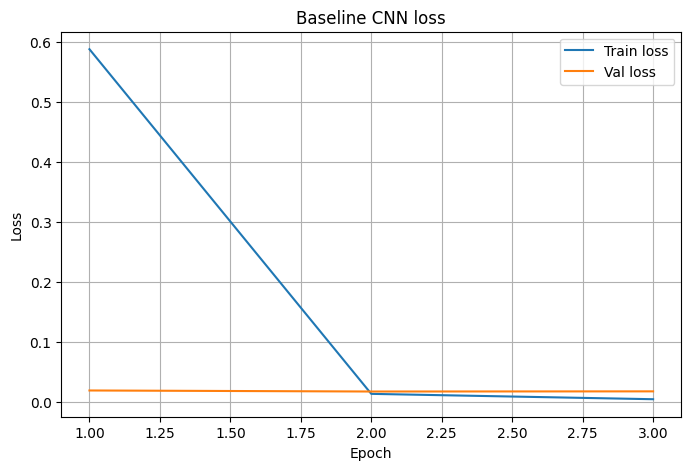

In [10]:
plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_loss"], label="Train loss")
plt.plot(history_df["epoch"], history_df["val_loss"], label="Val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Baseline CNN loss")
plt.legend()
plt.grid(True)
plt.show()

* __Show Validation Accuracy as a Chart__

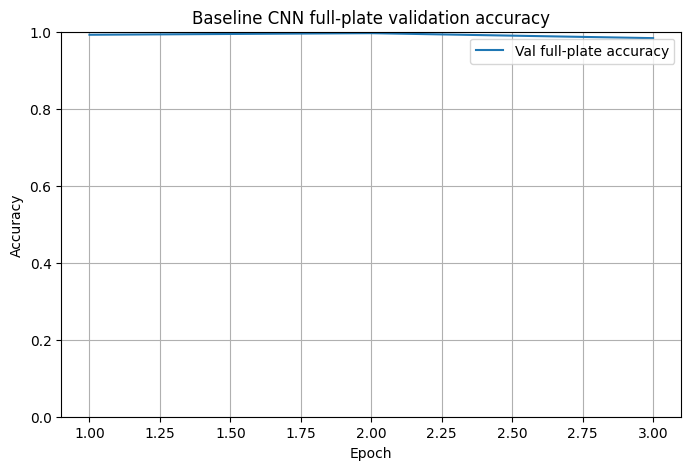

In [11]:
plt.figure(figsize=(8, 5))
plt.plot(
    history_df["epoch"],
    history_df["val_full_plate_accuracy"],
    label="Val full-plate accuracy",
)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Baseline CNN full-plate validation accuracy")
plt.ylim(0, 1)
plt.legend()
plt.grid(True)
plt.show()

* __Show Validation Accuracy per Each Character's Position__

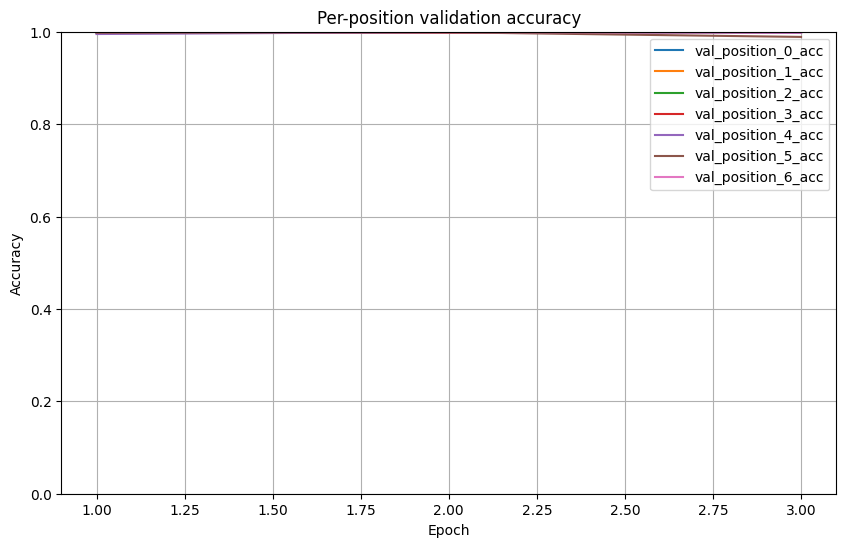

In [12]:
position_cols = [
    "val_position_0_acc",
    "val_position_1_acc",
    "val_position_2_acc",
    "val_position_3_acc",
    "val_position_4_acc",
    "val_position_5_acc",
    "val_position_6_acc",
]

plt.figure(figsize=(10, 6))

for col in position_cols:
    plt.plot(history_df["epoch"], history_df[col], label=col)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Per-position validation accuracy")
plt.ylim(0, 1)
plt.legend()
plt.grid(True)
plt.show()

* __Show Decoded Model's Predictions vs True Labels__

In [13]:
model.eval()

batch = next(iter(val_loader))

images = batch["image"].to(device)
labels = list(batch["label"])

with torch.no_grad():
    outputs = model(images)

predictions = decode_model_outputs(outputs)

for true_label, prediction in zip(labels[:20], predictions[:20]):
    print(
        f"True: {true_label} | "
        f"Pred: {prediction.cleaned_prediction} | "
        f"Correct: {prediction.cleaned_prediction == true_label} | "
        f"Conf: {prediction.overall_confidence:.4f}"
    )

True: AA79QWG | Pred: AA79QWG | Correct: True | Conf: 0.9961
True: AA86DYR | Pred: AA86DYR | Correct: True | Conf: 0.9938
True: AB45OUH | Pred: AB45OUH | Correct: True | Conf: 0.9961
True: AB57DMS | Pred: AB57DMS | Correct: True | Conf: 0.9951
True: AB86FAU | Pred: AB86FAU | Correct: True | Conf: 0.9959
True: AC75WEJ | Pred: AC75WEJ | Correct: True | Conf: 0.9912
True: AD64MHP | Pred: AD64MHP | Correct: True | Conf: 0.9873
True: AF25MYU | Pred: AF25MYU | Correct: True | Conf: 0.9971
True: AG44ZPB | Pred: AG44ZPB | Correct: True | Conf: 0.9925
True: AG73ABH | Pred: AG73ABH | Correct: True | Conf: 0.9978
True: AG94UXP | Pred: AG94UXP | Correct: True | Conf: 0.9894
True: AH26VNC | Pred: AH26VNC | Correct: True | Conf: 0.9975
True: AH32MTZ | Pred: AH32MTZ | Correct: True | Conf: 0.9980
True: AI19LSV | Pred: AI19LSV | Correct: True | Conf: 0.8976
True: AI79FCW | Pred: AI79FCW | Correct: True | Conf: 0.9940
True: AJ23SED | Pred: AJ23SED | Correct: True | Conf: 0.9850
True: AJ53JJY | Pred: AJ

* __Load Model with Best Validation Score__

In [7]:
CHECKPOINT_PATH = PROJECT_ROOT / "checkpoints" / "baseline_cnn" / "plate_cnn_baseline_best.pt"

checkpoint = torch.load(
    CHECKPOINT_PATH,
    map_location=device,
)

checkpoint["epoch"], checkpoint["best_val_accuracy"], checkpoint["model_config"]

(2,
 0.99625,
 {'in_channels': 1,
  'dropout': 0.1,
  'pooled_width': 10,
  'image_height': 48,
  'image_width': 160,
  'grayscale': True})

* __Declare new CNN Model with Best Model's Configuration__

In [ ]:
model_config = checkpoint["model_config"]

best_model = PlateCNN(
    in_channels=model_config["in_channels"],
    dropout=model_config["dropout"],
    pooled_width=model_config["pooled_width"],
).to(device)

best_model.load_state_dict(checkpoint["model_state_dict"])
best_model.eval()

loss_fn = PlateMultiHeadLoss()

* __Test Model on Test Data__

In [9]:
test_result = evaluate_one_epoch(
    model=best_model,
    dataloader=test_loader,
    loss_fn=loss_fn,
    device=device,
    show_progress=True,
)

print("Test loss:", test_result.loss)
print(format_plate_metrics(test_result.metrics))

Test loss: 0.018836233193675677
Samples: 2400
Full-plate accuracy: 0.9950
Regex-valid rate: 1.0000
Average confidence: 0.9845
Per-position accuracy:
  Position 0: 1.0000
  Position 1: 1.0000
  Position 2: 0.9996
  Position 3: 0.9988
  Position 4: 0.9971
  Position 5: 0.9979
  Position 6: 0.9988


* __Save Model's Predictions on Test Data to CSV file__

In [10]:
from anpr.inference.decode import decode_model_outputs


rows = []

best_model.eval()

with torch.no_grad():
    for batch in test_loader:
        images = batch["image"].to(device)
        labels = list(batch["label"])
        image_paths = list(batch["image_path"])

        outputs = best_model(images)
        predictions = decode_model_outputs(outputs)

        for image_path, true_label, prediction in zip(image_paths, labels, predictions):
            predicted_label = prediction.cleaned_prediction

            row = {
                "image_path": image_path,
                "true_label": true_label,
                "predicted_label": predicted_label,
                "correct": predicted_label == true_label,
                "confidence": prediction.overall_confidence,
                "regex_valid": prediction.is_valid_format,
            }

            for position in range(7):
                row[f"true_pos_{position}"] = true_label[position]
                row[f"pred_pos_{position}"] = predicted_label[position]
                row[f"pos_{position}_correct"] = true_label[position] == predicted_label[position]
                row[f"pos_{position}_confidence"] = prediction.position_confidences[position]

            rows.append(row)

test_predictions_df = pd.DataFrame(rows)

OUTPUT_DIR = PROJECT_ROOT / "outputs" / "predictions"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

test_predictions_path = OUTPUT_DIR / "baseline_test_predictions.csv"
test_predictions_df.to_csv(test_predictions_path, index=False)

test_predictions_df.head()

,image_path,true_label,predicted_label,correct,confidence,regex_valid,true_pos_0,pred_pos_0,pos_0_correct,pos_0_confidence,...,pos_4_correct,pos_4_confidence,true_pos_5,pred_pos_5,pos_5_correct,pos_5_confidence,true_pos_6,pred_pos_6,pos_6_correct,pos_6_confidence
0,C:\Users\kosko\OneDrive\Python\machine_learnin...,AA39HMS,AA39HMS,True,0.988080,True,A,A,True,0.980634,...,True,0.989045,M,M,True,0.988419,S,S,True,0.980299
1,C:\Users\kosko\OneDrive\Python\machine_learnin...,AB42XID,AB42XID,True,0.982491,True,A,A,True,0.966917,...,True,0.987056,I,I,True,0.997501,D,D,True,0.949292
2,C:\Users\kosko\OneDrive\Python\machine_learnin...,AB81EXE,AB81EXE,True,0.988167,True,A,A,True,0.965042,...,True,0.999225,X,X,True,0.982817,E,E,True,0.999145
3,C:\Users\kosko\OneDrive\Python\machine_learnin...,AB88VEK,AB88VEK,True,0.986711,True,A,A,True,0.973695,...,True,0.998364,E,E,True,0.999350,K,K,True,0.985865
4,C:\Users\kosko\OneDrive\Python\machine_learnin...,AC76RNT,AC76RNT,True,0.986701,True,A,A,True,0.983409,...,True,0.976067,N,N,True,0.992834,T,T,True,0.989497


In [11]:
test_predictions_df["correct"].mean()

np.float64(0.995)

* __Inspect Errors Model Made during Testing__

In [12]:
errors_df = test_predictions_df[~test_predictions_df["correct"]].copy()

print("Number of test errors:", len(errors_df))
print("Test full-plate accuracy:", test_predictions_df["correct"].mean())

errors_df.sort_values("confidence", ascending=False).head(20)

Number of test errors: 12
Test full-plate accuracy: 0.995


,image_path,true_label,predicted_label,correct,confidence,regex_valid,true_pos_0,pred_pos_0,pos_0_correct,pos_0_confidence,...,pos_4_correct,pos_4_confidence,true_pos_5,pred_pos_5,pos_5_correct,pos_5_confidence,true_pos_6,pred_pos_6,pos_6_correct,pos_6_confidence
2378,C:\Users\kosko\OneDrive\Python\machine_learnin...,ZO11ZUT,ZO11DUT,False,0.902639,True,Z,Z,True,0.995803,...,False,0.552073,U,U,True,0.907824,T,T,True,0.885665
1619,C:\Users\kosko\OneDrive\Python\machine_learnin...,IT16DOX,IT15DOX,False,0.890470,True,I,I,True,0.997902,...,True,0.991664,O,O,True,0.840349,X,X,True,0.771627
1642,C:\Users\kosko\OneDrive\Python\machine_learnin...,JI31ORP,JI31DRP,False,0.885627,True,J,J,True,0.996473,...,False,0.456871,R,R,True,0.922532,P,P,True,0.839524
453,C:\Users\kosko\OneDrive\Python\machine_learnin...,IX18TCO,IX15TCO,False,0.879734,True,I,I,True,0.997117,...,True,0.946152,C,C,True,0.925348,O,O,True,0.868058
1473,C:\Users\kosko\OneDrive\Python\machine_learnin...,FL11LGA,FL11EGA,False,0.832661,True,F,F,True,0.995122,...,False,0.408374,G,G,True,0.913073,A,A,True,0.514185
1227,C:\Users\kosko\OneDrive\Python\machine_learnin...,ZY11IMU,ZY11IUU,False,0.831122,True,Z,Z,True,0.995412,...,True,0.901036,M,U,False,0.545960,U,U,True,0.388392
2315,C:\Users\kosko\OneDrive\Python\machine_learnin...,YI13MPC,YI13WPC,False,0.815998,True,Y,Y,True,0.990008,...,False,0.449732,P,P,True,0.949416,C,C,True,0.838647
450,C:\Users\kosko\OneDrive\Python\machine_learnin...,IV71IZC,IV71ZDC,False,0.812742,True,I,I,True,0.982250,...,False,0.663859,Z,D,False,0.707407,C,C,True,0.389875
164,C:\Users\kosko\OneDrive\Python\machine_learnin...,DI81IDB,DI81IBG,False,0.810499,True,D,D,True,0.999101,...,True,0.682644,D,B,False,0.866643,B,G,False,0.222730
1578,C:\Users\kosko\OneDrive\Python\machine_learnin...,IA71IBO,IA71BDO,False,0.764947,True,I,I,True,0.997065,...,False,0.537503,B,D,False,0.641364,O,O,True,0.256199


* __Inspect Model's Errors per each Char__

In [ ]:
position_error_summary = []

for position in range(7):
    acc = test_predictions_df[f"pos_{position}_correct"].mean()
    errors = (~test_predictions_df[f"pos_{position}_correct"]).sum()

    position_error_summary.append(
        {
            "position": position,
            "accuracy": acc,
            "errors": errors,
        }
    )

position_error_df = pd.DataFrame(position_error_summary)
position_error_df

,position,accuracy,errors
0,0,1.000000,0
1,1,1.000000,0
2,2,0.999583,1
3,3,0.998750,3
4,4,0.997083,7
5,5,0.997917,5
6,6,0.998750,3


* __Confusion Matrix to Inspect what Chars have Error in Prediction__

In [14]:
confusion_rows = []

for position in range(7):
    wrong_pos_df = test_predictions_df[
        ~test_predictions_df[f"pos_{position}_correct"]
    ]

    for _, row in wrong_pos_df.iterrows():
        confusion_rows.append(
            {
                "position": position,
                "true_char": row[f"true_pos_{position}"],
                "pred_char": row[f"pred_pos_{position}"],
                "confidence": row[f"pos_{position}_confidence"],
                "true_label": row["true_label"],
                "predicted_label": row["predicted_label"],
                "image_path": row["image_path"],
            }
        )

confusion_df = pd.DataFrame(confusion_rows)

if not confusion_df.empty:
    display(
        confusion_df
        .groupby(["position", "true_char", "pred_char"])
        .size()
        .reset_index(name="count")
        .sort_values("count", ascending=False)
        .head(30)
    )
else:
    print("No character-level errors found.")

,position,true_char,pred_char,count
0,2,1,8,1
1,3,6,5,1
2,3,8,5,1
3,3,8,6,1
4,4,G,K,1
5,4,I,B,1
6,4,I,Z,1
7,4,L,E,1
8,4,M,W,1
9,4,O,D,1


* __Inspect 12 Wrong Predictions Visually__

In [17]:
def resolve_image_path(path_value):
    path = Path(path_value)

    if path.is_absolute():
        return path

    return PROJECT_ROOT / path


def show_error_images(errors_df, max_images=12):
    rows = errors_df.head(max_images).reset_index(drop=True)

    num_images = len(rows)

    if num_images == 0:
        print("No errors to display.")
        return

    cols = 3
    plot_rows = (num_images + cols - 1) // cols

    plt.figure(figsize=(16, 4 * plot_rows))

    for i, row in rows.iterrows():
        image_path = resolve_image_path(row["image_path"])

        image = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)

        if image is None:
            print(f"Could not read image: {image_path}")
            continue

        plt.subplot(plot_rows, cols, i + 1)
        plt.imshow(image, cmap="gray")

        title = (
            f"True: {row['true_label']}\n"
            f"Pred: {row['predicted_label']}\n"
            f"Conf: {row['confidence']:.4f}"
        )

        plt.title(title)
        plt.axis("off")

    plt.tight_layout()
    plt.show()


# show_error_images(
#     errors_df.sort_values("confidence", ascending=False),
#     max_images=12,
# )

* __Visualuse Low Confidence Correct Predictions__

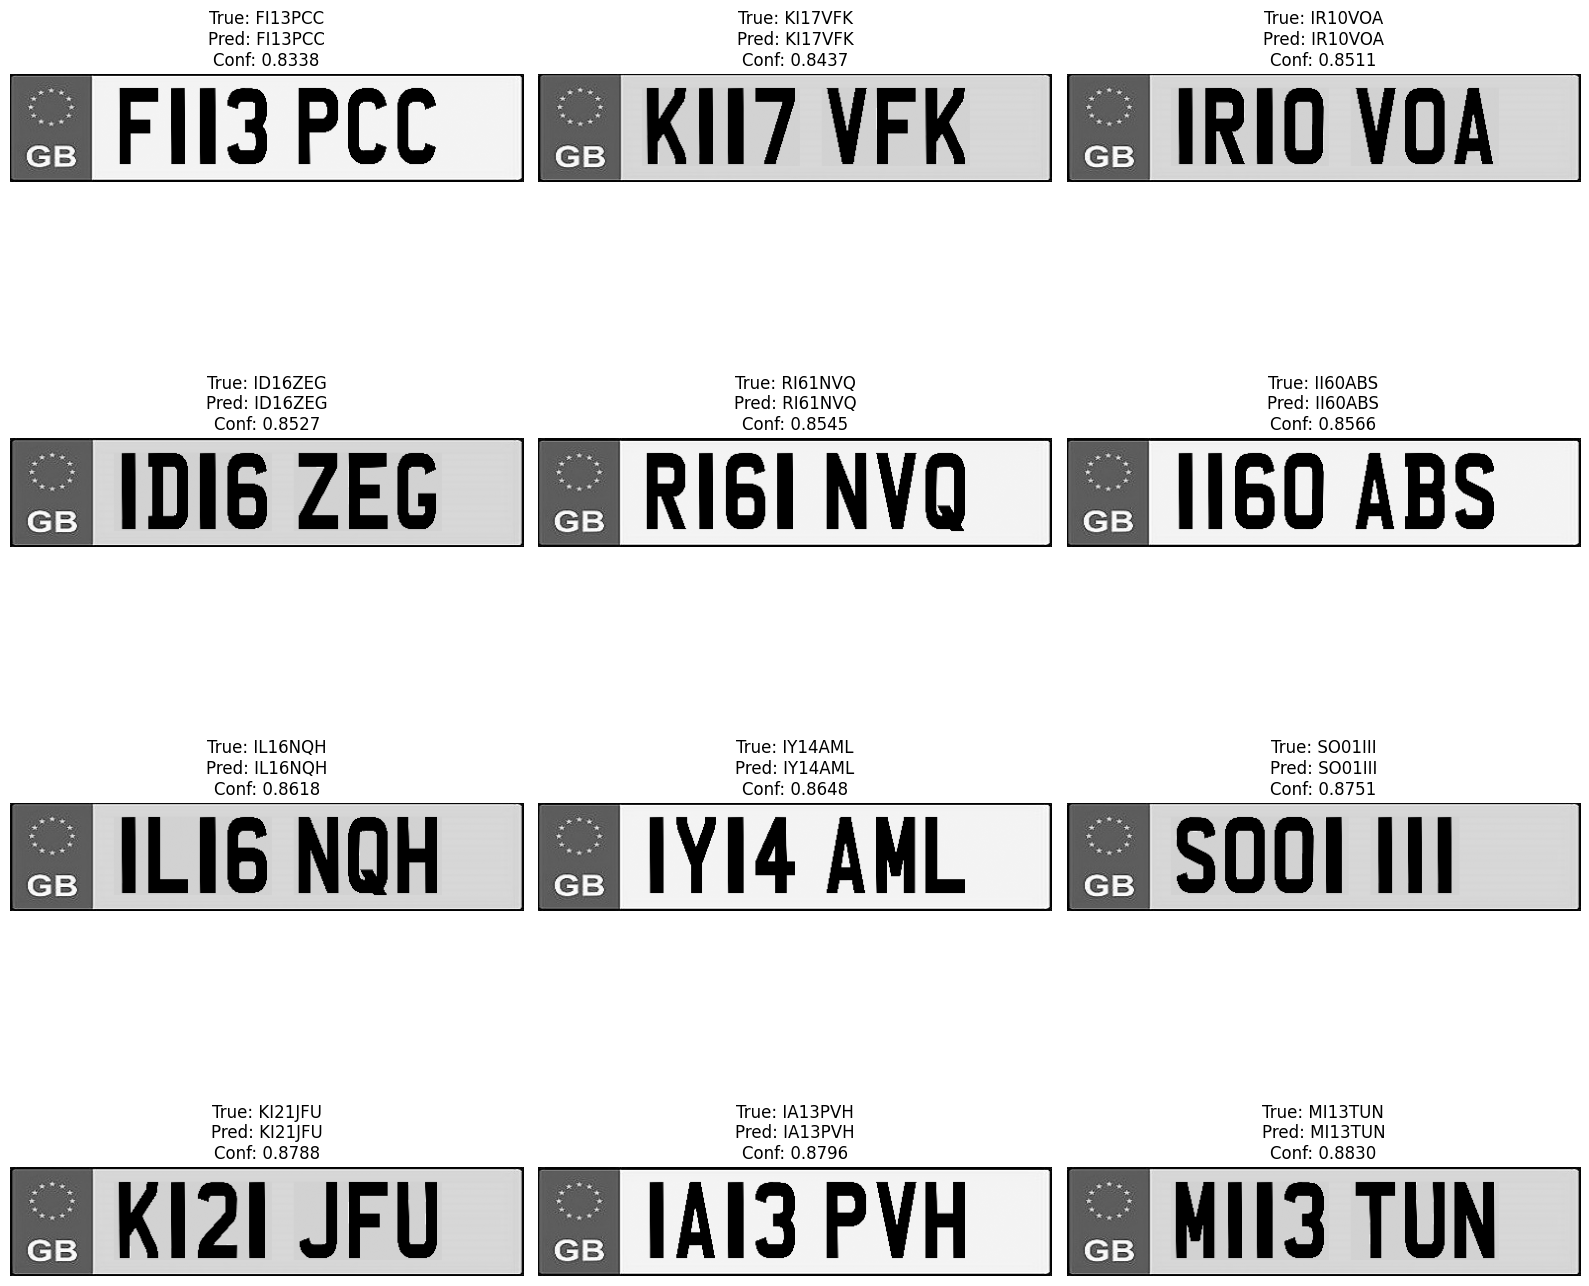

In [17]:
low_conf_correct_df = (
    test_predictions_df[test_predictions_df["correct"]]
    .sort_values("confidence", ascending=True)
    .head(20)
)

low_conf_correct_df[
    [
        "image_path",
        "true_label",
        "predicted_label",
        "confidence",
    ]
]

show_error_images(
    low_conf_correct_df,
    max_images=12,
)

* __Create DataFRame with wrong predictions__

In [18]:
char_error_rows = []

for _, row in errors_df.iterrows():
    true_label = row["true_label"]
    predicted_label = row["predicted_label"]

    for position in range(7):
        true_char = true_label[position]
        pred_char = predicted_label[position]

        if true_char != pred_char:
            char_error_rows.append(
                {
                    "image_path": row["image_path"],
                    "true_label": true_label,
                    "predicted_label": predicted_label,
                    "position": position,
                    "true_char": true_char,
                    "pred_char": pred_char,
                    "plate_confidence": row["confidence"],
                    "position_confidence": row[f"pos_{position}_confidence"],
                }
            )

char_errors_df = pd.DataFrame(char_error_rows)

char_errors_df.sort_values(
    ["position", "position_confidence"],
    ascending=[True, False],
)

,image_path,true_label,predicted_label,position,true_char,pred_char,plate_confidence,position_confidence
2,C:\Users\kosko\OneDrive\Python\machine_learnin...,II18GKJ,II86KDL,2,1,8,0.641157,0.475053
3,C:\Users\kosko\OneDrive\Python\machine_learnin...,II18GKJ,II86KDL,3,8,6,0.641157,0.984736
15,C:\Users\kosko\OneDrive\Python\machine_learnin...,IT16DOX,IT15DOX,3,6,5,0.890470,0.752932
10,C:\Users\kosko\OneDrive\Python\machine_learnin...,IX18TCO,IX15TCO,3,8,5,0.879734,0.539788
7,C:\Users\kosko\OneDrive\Python\machine_learnin...,IV71IZC,IV71ZDC,4,I,Z,0.812742,0.663859
18,C:\Users\kosko\OneDrive\Python\machine_learnin...,ZO11ZUT,ZO11DUT,4,Z,D,0.902639,0.552073
13,C:\Users\kosko\OneDrive\Python\machine_learnin...,IA71IBO,IA71BDO,4,I,B,0.764947,0.537503
16,C:\Users\kosko\OneDrive\Python\machine_learnin...,JI31ORP,JI31DRP,4,O,D,0.885627,0.456871
17,C:\Users\kosko\OneDrive\Python\machine_learnin...,YI13MPC,YI13WPC,4,M,W,0.815998,0.449732
12,C:\Users\kosko\OneDrive\Python\machine_learnin...,FL11LGA,FL11EGA,4,L,E,0.832661,0.408374


* __Analyse how many wrong predictions per each char__ 

In [19]:
char_errors_df.groupby("position").size().reset_index(name="num_errors")

,position,num_errors
0,2,1
1,3,3
2,4,7
3,5,5
4,6,3


* __Use augmentated data for training__

In [5]:
image_height = 48
image_width = 160

train_transform = get_train_transforms(
    image_height=image_height,
    image_width=image_width,
)

eval_transform = get_eval_transforms(
    image_height=image_height,
    image_width=image_width,
)

In [6]:
train_ds = PlateDataset(
    metadata=METADATA_CSV,
    project_root=PROJECT_ROOT,
    split="train",
    transform=train_transform,
    grayscale=True,
)

val_ds = PlateDataset(
    metadata=METADATA_CSV,
    project_root=PROJECT_ROOT,
    split="val",
    transform=eval_transform,
    grayscale=True,
)

test_ds = PlateDataset(
    metadata=METADATA_CSV,
    project_root=PROJECT_ROOT,
    split="test",
    transform=eval_transform,
    grayscale=True,
)

* __Visualise aug data__

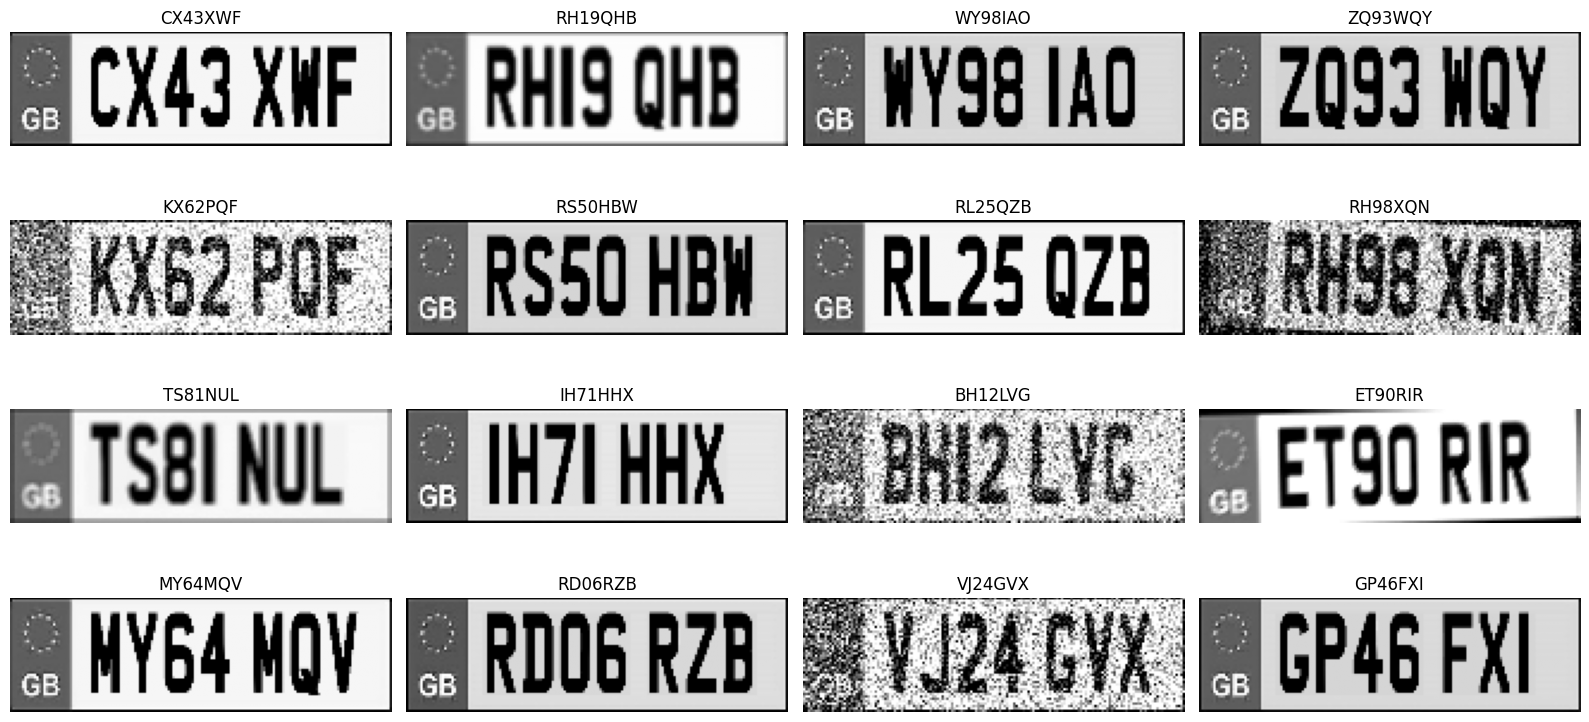

In [13]:
aug_loader = DataLoader(
    train_ds,
    batch_size=16,
    shuffle=True,
    num_workers=0,
)

batch = next(iter(aug_loader))


def denormalise_plate_tensor(image_tensor):
    image = image_tensor.squeeze(0).detach().cpu().numpy()
    image = (image * 0.5) + 0.5
    image = image.clip(0, 1)
    return image


plt.figure(figsize=(16, 8))

for i in range(16):
    plt.subplot(4, 4, i + 1)
    image = denormalise_plate_tensor(batch["image"][i])
    plt.imshow(image, cmap="gray")
    plt.title(batch["label"][i])
    plt.axis("off")

plt.tight_layout()
plt.show()

* __Declare aug model__

In [14]:
model = PlateCNN(
    in_channels=1,
    dropout=0.1,
    pooled_width=10,
).to(device)

loss_fn = PlateMultiHeadLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4,
)

* __Declare aug loaders__

In [7]:
batch_size = 64

train_loader = DataLoader(
    train_ds,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

val_loader = DataLoader(
    val_ds,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

test_loader = DataLoader(
    test_ds,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

* __Store paths for reusability__

In [20]:
CHECKPOINT_DIR = PROJECT_ROOT / "checkpoints" / "baseline_cnn"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_DIR = PROJECT_ROOT / "outputs" / "predictions"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


best_checkpoint_path = CHECKPOINT_DIR / "plate_cnn_baseline_aug_best.pt"

* __Aug model training__

In [ ]:
best_val_accuracy = 0.0
num_epochs = 5
history = []

for epoch in range(1, num_epochs + 1):
    train_result = train_one_epoch(
        model=model,
        dataloader=train_loader,
        loss_fn=loss_fn,
        optimizer=optimizer,
        device=device,
        show_progress=True,
    )

    val_result = evaluate_one_epoch(
        model=model,
        dataloader=val_loader,
        loss_fn=loss_fn,
        device=device,
        show_progress=True,
    )

    val_metrics = val_result.metrics

    row = {
        "epoch": epoch,
        "train_loss": train_result.loss,
        "val_loss": val_result.loss,
        "val_full_plate_accuracy": val_metrics.full_plate_accuracy,
        "val_regex_valid_rate": val_metrics.regex_valid_rate,
        "val_average_confidence": val_metrics.average_confidence,
        "val_position_0_acc": val_metrics.per_position_accuracy[0],
        "val_position_1_acc": val_metrics.per_position_accuracy[1],
        "val_position_2_acc": val_metrics.per_position_accuracy[2],
        "val_position_3_acc": val_metrics.per_position_accuracy[3],
        "val_position_4_acc": val_metrics.per_position_accuracy[4],
        "val_position_5_acc": val_metrics.per_position_accuracy[5],
        "val_position_6_acc": val_metrics.per_position_accuracy[6],
    }

    history.append(row)

    print(
        f"Epoch {epoch:02d} | "
        f"train_loss={train_result.loss:.4f} | "
        f"val_loss={val_result.loss:.4f} | "
        f"val_full_plate_acc={val_metrics.full_plate_accuracy:.4f} | "
        f"confidence={val_metrics.average_confidence:.4f}"
    )

    if val_metrics.full_plate_accuracy > best_val_accuracy:
        best_val_accuracy = val_metrics.full_plate_accuracy

        torch.save(
            {
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "epoch": epoch,
                "best_val_accuracy": best_val_accuracy,
                "history": history,
                "model_config": {
                    "in_channels": 1,
                    "dropout": 0.1,
                    "pooled_width": 10,
                    "image_height": 48,
                    "image_width": 160,
                    "grayscale": True,
                },
            },
            best_checkpoint_path,
        )

        print(f"Saved new best checkpoint: {best_checkpoint_path}")

Epoch 01 | train_loss=0.9776 | val_loss=0.0658 | val_full_plate_acc=0.9692 | confidence=0.9526
Saved new best checkpoint: C:\Users\kosko\OneDrive\Python\machine_learning\Projects\Car-Parking\uk_plate_recognition\checkpoints\baseline_cnn\plate_cnn_baseline_aug_best.pt


Epoch 02 | train_loss=0.0784 | val_loss=0.0197 | val_full_plate_acc=0.9883 | confidence=0.9885
Saved new best checkpoint: C:\Users\kosko\OneDrive\Python\machine_learning\Projects\Car-Parking\uk_plate_recognition\checkpoints\baseline_cnn\plate_cnn_baseline_aug_best.pt


Epoch 03 | train_loss=0.0487 | val_loss=0.0153 | val_full_plate_acc=0.9854 | confidence=0.9939


Epoch 04 | train_loss=0.0367 | val_loss=0.0105 | val_full_plate_acc=0.9912 | confidence=0.9967
Saved new best checkpoint: C:\Users\kosko\OneDrive\Python\machine_learning\Projects\Car-Parking\uk_plate_recognition\checkpoints\baseline_cnn\plate_cnn_baseline_aug_best.pt


Epoch 05 | train_loss=0.0297 | val_loss=0.0083 | val_full_plate_acc=0.9900 | confidence=0.9977


* __Loading aug model with best result__

In [7]:
CHECKPOINT_PATH = PROJECT_ROOT / "checkpoints" / "baseline_cnn" / "plate_cnn_baseline_aug_best.pt"

checkpoint = torch.load(
    CHECKPOINT_PATH,
    map_location=device,
)

model_config = checkpoint["model_config"]

best_model = PlateCNN(
    in_channels=model_config["in_channels"],
    dropout=model_config["dropout"],
    pooled_width=model_config["pooled_width"],
).to(device)

best_model.load_state_dict(checkpoint["model_state_dict"])
best_model.eval()

loss_fn = PlateMultiHeadLoss()

* __Evaluating aug model's result__

In [12]:
test_result = evaluate_one_epoch(
    model=best_model,
    dataloader=test_loader,
    loss_fn=loss_fn,
    device=device,
    show_progress=True,
)

print("Test loss:", test_result.loss)
print(format_plate_metrics(test_result.metrics))

Test loss: 0.01100448791248103
Samples: 2400
Full-plate accuracy: 0.9900
Regex-valid rate: 1.0000
Average confidence: 0.9966
Per-position accuracy:
  Position 0: 1.0000
  Position 1: 1.0000
  Position 2: 0.9992
  Position 3: 0.9975
  Position 4: 0.9967
  Position 5: 0.9950
  Position 6: 0.9979


* __Testing model on test data and saving as a csv file__

In [ ]:
from anpr.inference.decode import decode_model_outputs


rows = []

best_model.eval()

with torch.no_grad():
    for batch in test_loader:
        images = batch["image"].to(device)
        labels = list(batch["label"])
        image_paths = list(batch["image_path"])

        outputs = best_model(images)
        predictions = decode_model_outputs(outputs)

        for image_path, true_label, prediction in zip(image_paths, labels, predictions):
            predicted_label = prediction.cleaned_prediction

            row = {
                "image_path": image_path,
                "true_label": true_label,
                "predicted_label": predicted_label,
                "correct": predicted_label == true_label,
                "confidence": prediction.overall_confidence,
                "regex_valid": prediction.is_valid_format,
            }

            for position in range(7):
                row[f"true_pos_{position}"] = true_label[position]
                row[f"pred_pos_{position}"] = predicted_label[position]
                row[f"pos_{position}_correct"] = true_label[position] == predicted_label[position]
                row[f"pos_{position}_confidence"] = prediction.position_confidences[position]

            rows.append(row)

test_predictions_df = pd.DataFrame(rows)

OUTPUT_DIR = PROJECT_ROOT / "outputs" / "predictions"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

test_predictions_path = OUTPUT_DIR / "baseline_aug_test_predictions.csv"
test_predictions_df.to_csv(test_predictions_path, index=False)

test_predictions_df.head()

,image_path,true_label,predicted_label,correct,confidence,regex_valid,true_pos_0,pred_pos_0,pos_0_correct,pos_0_confidence,...,pos_4_correct,pos_4_confidence,true_pos_5,pred_pos_5,pos_5_correct,pos_5_confidence,true_pos_6,pred_pos_6,pos_6_correct,pos_6_confidence
0,C:\Users\kosko\OneDrive\Python\machine_learnin...,AA39HMS,AA39HMS,True,0.999396,True,A,A,True,0.999517,...,True,0.999487,M,M,True,0.999532,S,S,True,0.999818
1,C:\Users\kosko\OneDrive\Python\machine_learnin...,AB42XID,AB42XID,True,0.999265,True,A,A,True,0.999387,...,True,0.999928,I,I,True,0.999898,D,D,True,0.999487
2,C:\Users\kosko\OneDrive\Python\machine_learnin...,AB81EXE,AB81EXE,True,0.999126,True,A,A,True,0.998778,...,True,0.996736,X,X,True,0.999334,E,E,True,0.999917
3,C:\Users\kosko\OneDrive\Python\machine_learnin...,AB88VEK,AB88VEK,True,0.997106,True,A,A,True,0.999399,...,True,0.999654,E,E,True,0.981473,K,K,True,0.999996
4,C:\Users\kosko\OneDrive\Python\machine_learnin...,AC76RNT,AC76RNT,True,0.999159,True,A,A,True,0.999151,...,True,0.997823,N,N,True,0.997711,T,T,True,0.999855


* __Inspecting wrong predictions__

In [14]:
errors_df = test_predictions_df[~test_predictions_df["correct"]].copy()

print("Number of test errors:", len(errors_df))
print("Test full-plate accuracy:", test_predictions_df["correct"].mean())

errors_df.sort_values("confidence", ascending=False).head(20)

Number of test errors: 24
Test full-plate accuracy: 0.99


,image_path,true_label,predicted_label,correct,confidence,regex_valid,true_pos_0,pred_pos_0,pos_0_correct,pos_0_confidence,...,pos_4_correct,pos_4_confidence,true_pos_5,pred_pos_5,pos_5_correct,pos_5_confidence,true_pos_6,pred_pos_6,pos_6_correct,pos_6_confidence
2031,C:\Users\kosko\OneDrive\Python\machine_learnin...,SI95IQS,SI95ISS,False,0.990000,True,S,S,True,0.999180,...,True,0.999634,Q,S,False,0.966767,S,S,True,0.969722
423,C:\Users\kosko\OneDrive\Python\machine_learnin...,II60ABS,II00ABS,False,0.988057,True,I,I,True,0.999930,...,True,0.965711,B,B,True,0.975796,S,S,True,0.998931
1473,C:\Users\kosko\OneDrive\Python\machine_learnin...,FL11LGA,FL11GGA,False,0.981748,True,F,F,True,0.995281,...,False,0.910008,G,G,True,0.991500,A,A,True,0.996139
422,C:\Users\kosko\OneDrive\Python\machine_learnin...,II18GKJ,II86KJI,False,0.970281,True,I,I,True,0.999983,...,False,0.997325,K,J,False,0.993331,J,I,False,0.812216
1585,C:\Users\kosko\OneDrive\Python\machine_learnin...,ID16ZEG,ID16ZGG,False,0.964325,True,I,I,True,0.999978,...,True,0.984018,E,G,False,0.994140,G,G,True,0.842383
1227,C:\Users\kosko\OneDrive\Python\machine_learnin...,ZY11IMU,ZY11IUI,False,0.952111,True,Z,Z,True,0.999734,...,True,0.999712,M,U,False,0.979754,U,I,False,0.686121
267,C:\Users\kosko\OneDrive\Python\machine_learnin...,FI13PCC,FI19PCC,False,0.942982,True,F,F,True,0.996113,...,True,0.989673,C,C,True,0.998667,C,C,True,0.958109
224,C:\Users\kosko\OneDrive\Python\machine_learnin...,EI51RZQ,EI51PZQ,False,0.941679,True,E,E,True,0.998093,...,False,0.598653,Z,Z,True,0.998028,Q,Q,True,0.997505
164,C:\Users\kosko\OneDrive\Python\machine_learnin...,DI81IDB,DI81IBA,False,0.929448,True,D,D,True,0.998464,...,True,0.999999,D,B,False,0.996122,B,A,False,0.514790
1619,C:\Users\kosko\OneDrive\Python\machine_learnin...,IT16DOX,IT16OOX,False,0.928662,True,I,I,True,0.999444,...,False,0.666884,O,O,True,0.974145,X,X,True,0.987658


* __Inspecting per postion errors__

In [15]:
position_error_summary = []

for position in range(7):
    acc = test_predictions_df[f"pos_{position}_correct"].mean()
    errors = (~test_predictions_df[f"pos_{position}_correct"]).sum()

    position_error_summary.append(
        {
            "position": position,
            "accuracy": acc,
            "errors": errors,
        }
    )

position_error_df = pd.DataFrame(position_error_summary)
position_error_df

,position,accuracy,errors
0,0,1.000000,0
1,1,1.000000,0
2,2,0.999167,2
3,3,0.997500,6
4,4,0.996667,8
5,5,0.995000,12
6,6,0.997917,5


* __Inspecting wrong predicted images__

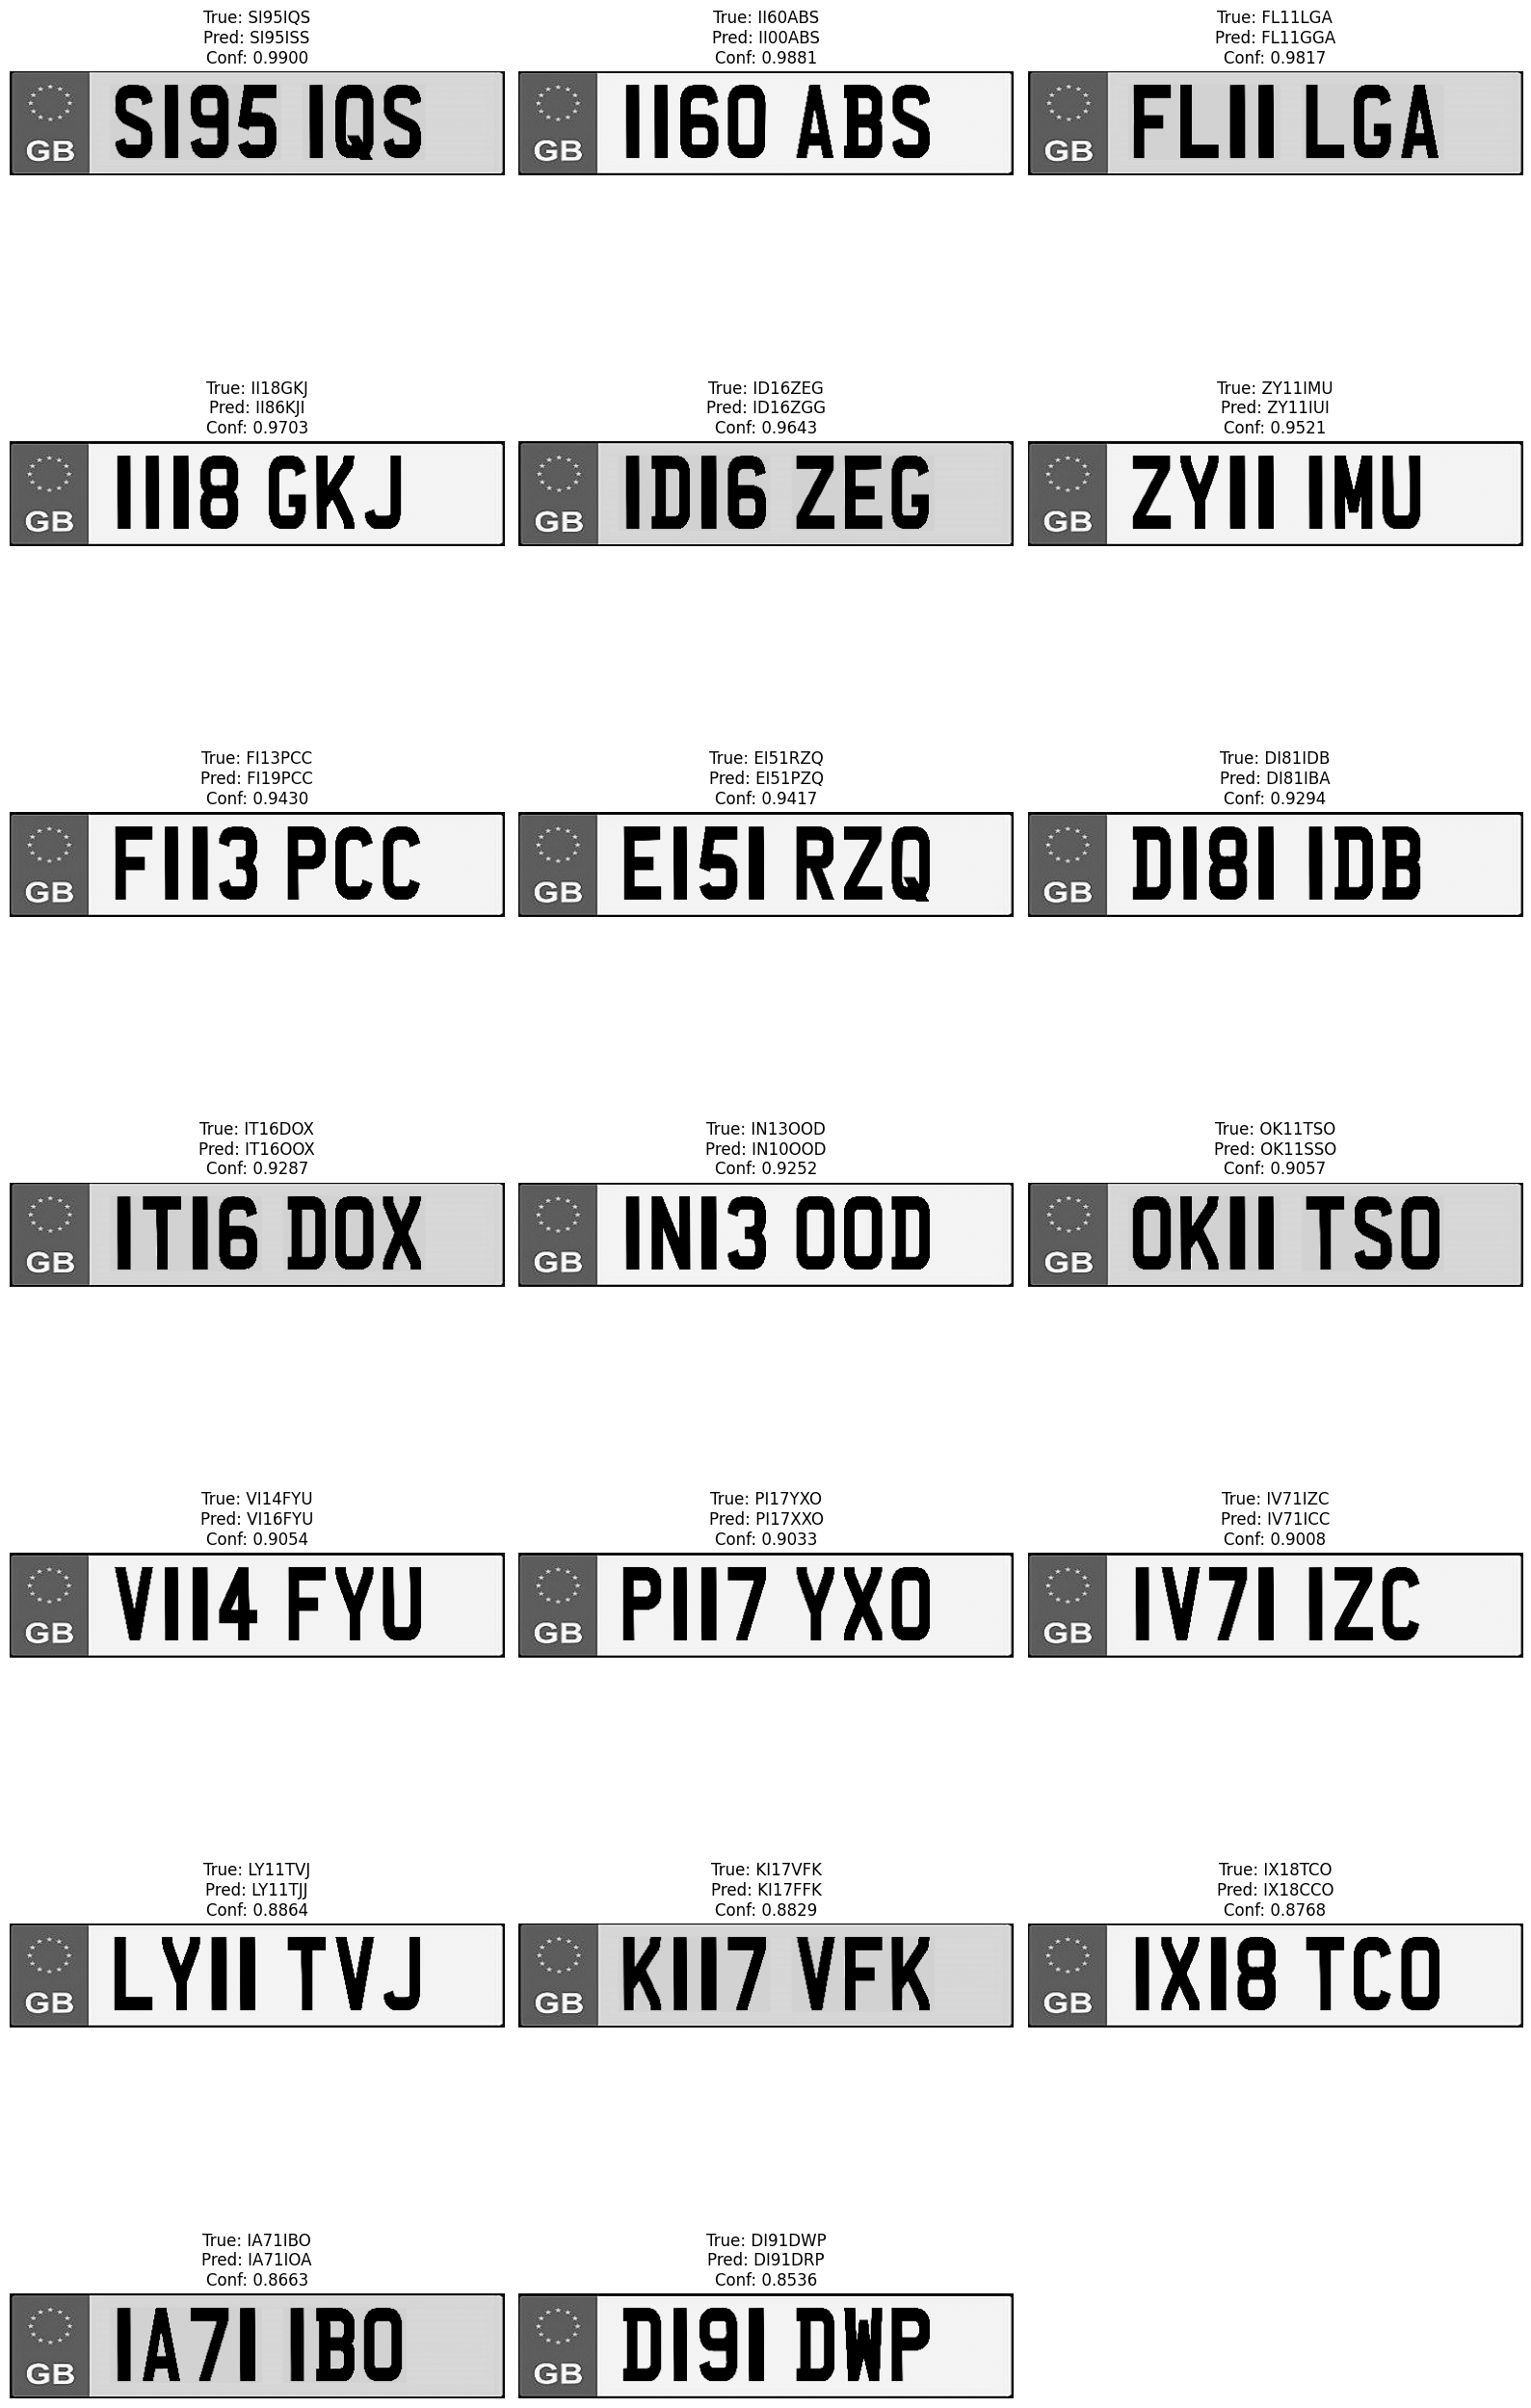

In [18]:
show_error_images(
    errors_df.sort_values("confidence", ascending=False),
    max_images=20,
)

* __Sress test for clean & aug models__

In [5]:
stress_transform = get_stress_test_transforms(
    image_height=48,
    image_width=160,
)

stress_test_ds = PlateDataset(
    metadata=METADATA_CSV,
    project_root=PROJECT_ROOT,
    split="test",
    transform=stress_transform,
    grayscale=True,
)

stress_test_loader = DataLoader(
    stress_test_ds,
    batch_size=64,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

C:\Users\kosko\OneDrive\Python\machine_learning\Projects\Car-Parking\uk_plate_recognition\src\anpr\data\transforms.py:129: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(
C:\Users\kosko\OneDrive\Python\machine_learning\Projects\Car-Parking\uk_plate_recognition\src\anpr\data\transforms.py:134: UserWarning: Argument(s) 'quality_lower, quality_upper' are not valid for transform ImageCompression
  A.ImageCompression(


* __Loading both models__

In [9]:
CLEAN_CHECKPOINT_PATH = PROJECT_ROOT / "checkpoints" / "baseline_cnn" / "plate_cnn_baseline_best.pt"
AUG_CHECKPOINT_PATH = PROJECT_ROOT / "checkpoints" / "baseline_cnn" / "plate_cnn_baseline_aug_best.pt"
#################################################################################################################################
clean_checkpoint = torch.load(
    CLEAN_CHECKPOINT_PATH,
    map_location=device,
)
aug_checkpoint = torch.load(
    AUG_CHECKPOINT_PATH,
    map_location=device,
)

#################################################################################################################################
clean_model_config = clean_checkpoint["model_config"]
aug_model_config = aug_checkpoint["model_config"]

clean_best_model = PlateCNN(
    in_channels=clean_model_config["in_channels"],
    dropout=clean_model_config["dropout"],
    pooled_width=clean_model_config["pooled_width"],
).to(device)

clean_best_model.load_state_dict(clean_checkpoint["model_state_dict"])
clean_best_model.eval()
#################################################################################################################################
aug_best_model = PlateCNN(
    in_channels=aug_model_config["in_channels"],
    dropout=aug_model_config["dropout"],
    pooled_width=aug_model_config["pooled_width"],
).to(device)

aug_best_model.load_state_dict(aug_checkpoint["model_state_dict"])
aug_best_model.eval()
#################################################################################################################################
loss_fn = PlateMultiHeadLoss()

* __Inspecting results of predictions__

In [ ]:
clean_model_stress_result = evaluate_one_epoch(
    model=clean_best_model,
    dataloader=stress_test_loader,
    loss_fn=loss_fn,
    device=device,
    show_progress=True,
)

aug_model_stress_result = evaluate_one_epoch(
    model=aug_best_model,
    dataloader=stress_test_loader,
    loss_fn=loss_fn,
    device=device,
    show_progress=True,
)

print("Clean model on stress test:")
print(format_plate_metrics(clean_model_stress_result.metrics))

print("Augmented model on stress test:")
print(format_plate_metrics(aug_model_stress_result.metrics))

Clean model on stress test:
Samples: 2400
Full-plate accuracy: 0.2279
Regex-valid rate: 1.0000
Average confidence: 0.7022
Per-position accuracy:
  Position 0: 0.4000
  Position 1: 0.4325
  Position 2: 0.5787
  Position 3: 0.4942
  Position 4: 0.3779
  Position 5: 0.4100
  Position 6: 0.4275
Augmented model on stress test:
Samples: 2400
Full-plate accuracy: 0.8888
Regex-valid rate: 1.0000
Average confidence: 0.9627
Per-position accuracy:
  Position 0: 0.9867
  Position 1: 0.9871
  Position 2: 0.9833
  Position 3: 0.9933
  Position 4: 0.9783
  Position 5: 0.9354
  Position 6: 0.9704


* __Saving experiment results into csv file__

In [11]:
experiment_rows = [
    {
        "experiment": "clean_48x160",
        "image_size": "48x160",
        "train_augmentation": False,
        "best_val_accuracy": 0.9962,
        "clean_test_accuracy": 0.9950,
        "clean_test_errors": 12,
        "notes": "Best clean baseline. Trained without augmentation.",
    },
    {
        "experiment": "augmented_48x160",
        "image_size": "48x160",
        "train_augmentation": True,
        "best_val_accuracy": 0.9912,
        "clean_test_accuracy": 0.9900,
        "clean_test_errors": 24,
        "notes": "Lower clean accuracy, needs stress-test comparison.",
    },
]

experiment_df = pd.DataFrame(experiment_rows)

experiment_path = PROJECT_ROOT / "outputs" / "predictions" / "experiment_summary.csv"
experiment_df.to_csv(experiment_path, index=False)

experiment_df

,experiment,image_size,train_augmentation,best_val_accuracy,clean_test_accuracy,clean_test_errors,notes
0,clean_48x160,48x160,False,0.9962,0.995,12,Best clean baseline. Trained without augmentat...
1,augmented_48x160,48x160,True,0.9912,0.990,24,"Lower clean accuracy, needs stress-test compar..."


* __Function for running repeated stress test n times to get mean scores__

In [12]:
def run_repeated_stress_eval(
    model,
    model_name,
    num_runs=5,
):
    rows = []

    for run in range(1, num_runs + 1):
        result = evaluate_one_epoch(
            model=model,
            dataloader=stress_test_loader,
            loss_fn=loss_fn,
            device=device,
            show_progress=True,
        )

        metrics = result.metrics

        row = {
            "model": model_name,
            "run": run,
            "loss": result.loss,
            "full_plate_accuracy": metrics.full_plate_accuracy,
            "regex_valid_rate": metrics.regex_valid_rate,
            "average_confidence": metrics.average_confidence,
            "position_0_acc": metrics.per_position_accuracy[0],
            "position_1_acc": metrics.per_position_accuracy[1],
            "position_2_acc": metrics.per_position_accuracy[2],
            "position_3_acc": metrics.per_position_accuracy[3],
            "position_4_acc": metrics.per_position_accuracy[4],
            "position_5_acc": metrics.per_position_accuracy[5],
            "position_6_acc": metrics.per_position_accuracy[6],
        }

        rows.append(row)

        print(
            f"{model_name} | run {run} | "
            f"stress_acc={metrics.full_plate_accuracy:.4f} | "
            f"confidence={metrics.average_confidence:.4f}"
        )

    return pd.DataFrame(rows)

* __Running reapeted stess test__

In [13]:
clean_stress_runs_df = run_repeated_stress_eval(
    model=clean_best_model,
    model_name="clean_48x160",
    num_runs=5,
)

aug_stress_runs_df = run_repeated_stress_eval(
    model=aug_best_model,
    model_name="augmented_48x160",
    num_runs=5,
)

stress_runs_df = pd.concat(
    [clean_stress_runs_df, aug_stress_runs_df],
    ignore_index=True,
)

stress_runs_df

clean_48x160 | run 1 | stress_acc=0.2329 | confidence=0.7095


clean_48x160 | run 2 | stress_acc=0.2288 | confidence=0.7066


clean_48x160 | run 3 | stress_acc=0.2412 | confidence=0.7120


clean_48x160 | run 4 | stress_acc=0.2233 | confidence=0.7091


clean_48x160 | run 5 | stress_acc=0.2225 | confidence=0.7080


...

augmented_48x160 | run 2 | stress_acc=0.9054 | confidence=0.9657


augmented_48x160 | run 3 | stress_acc=0.9046 | confidence=0.9650


augmented_48x160 | run 4 | stress_acc=0.8917 | confidence=0.9628


augmented_48x160 | run 5 | stress_acc=0.8850 | confidence=0.9634


,model,run,loss,full_plate_accuracy,regex_valid_rate,average_confidence,position_0_acc,position_1_acc,position_2_acc,position_3_acc,position_4_acc,position_5_acc,position_6_acc
0,clean_48x160,1,3.345795,0.232917,1.0,0.709471,0.401250,0.436250,0.566250,0.497500,0.374167,0.407083,0.429167
1,clean_48x160,2,3.305511,0.228750,1.0,0.706610,0.415833,0.435833,0.580833,0.461250,0.369583,0.409167,0.427500
2,clean_48x160,3,3.311218,0.241250,1.0,0.712017,0.397083,0.437083,0.585833,0.493750,0.376667,0.413333,0.428750
3,clean_48x160,4,3.453596,0.223333,1.0,0.709078,0.393333,0.429583,0.571250,0.479167,0.359167,0.399583,0.417500
4,clean_48x160,5,3.395792,0.222500,1.0,0.708041,0.397500,0.430000,0.568333,0.479583,0.366667,0.398750,0.427917
5,augmented_48x160,1,0.087558,0.890417,1.0,0.964714,0.987500,0.985000,0.988750,0.993333,0.980417,0.944167,0.967500
6,augmented_48x160,2,0.085303,0.905417,1.0,0.965710,0.988750,0.988333,0.992917,0.992917,0.972083,0.950417,0.973333
7,augmented_48x160,3,0.082166,0.904583,1.0,0.965027,0.991667,0.985833,0.985000,0.991250,0.982083,0.951667,0.975417
8,augmented_48x160,4,0.096029,0.891667,1.0,0.962773,0.984167,0.984583,0.988333,0.990417,0.973333,0.935417,0.972500
9,augmented_48x160,5,0.099110,0.885000,1.0,0.963389,0.988333,0.983333,0.982500,0.990833,0.972083,0.936667,0.965417


* __Creating summary of a test__

In [14]:
stress_summary_df = (
    stress_runs_df
    .groupby("model")
    .agg(
        stress_acc_mean=("full_plate_accuracy", "mean"),
        stress_acc_std=("full_plate_accuracy", "std"),
        confidence_mean=("average_confidence", "mean"),
        confidence_std=("average_confidence", "std"),
        loss_mean=("loss", "mean"),
        loss_std=("loss", "std"),
    )
    .reset_index()
)

stress_summary_df

,model,stress_acc_mean,stress_acc_std,confidence_mean,confidence_std,loss_mean,loss_std
0,augmented_48x160,0.895417,0.009105,0.964322,0.001209,0.090033,0.007224
1,clean_48x160,0.229750,0.007698,0.709044,0.001997,3.362382,0.062377


* __Saving summary to the csv files__

In [ ]:
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "predictions"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

stress_runs_df.to_csv(
    OUTPUT_DIR / "stress_test_runs.csv",
    index=False,
)

stress_summary_df.to_csv(
    OUTPUT_DIR / "stress_test_summary.csv",
    index=False,
)

* __Training new models on higher resolution images: 64x192__

In [16]:
image_height = 64
image_width = 192

train_transform = get_eval_transforms(
    image_height=image_height,
    image_width=image_width,
)

eval_transform = get_eval_transforms(
    image_height=image_height,
    image_width=image_width,
)

In [17]:
train_ds_64 = PlateDataset(
    metadata=METADATA_CSV,
    project_root=PROJECT_ROOT,
    split="train",
    transform=train_transform,
    grayscale=True,
)

val_ds_64 = PlateDataset(
    metadata=METADATA_CSV,
    project_root=PROJECT_ROOT,
    split="val",
    transform=eval_transform,
    grayscale=True,
)

test_ds_64 = PlateDataset(
    metadata=METADATA_CSV,
    project_root=PROJECT_ROOT,
    split="test",
    transform=eval_transform,
    grayscale=True,
)

train_loader_64 = DataLoader(
    train_ds_64,
    batch_size=64,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

val_loader_64 = DataLoader(
    val_ds_64,
    batch_size=64,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

test_loader_64 = DataLoader(
    test_ds_64,
    batch_size=64,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

In [18]:
model_64 = PlateCNN(
    in_channels=1,
    dropout=0.1,
    pooled_width=10,
).to(device)

loss_fn = PlateMultiHeadLoss()

optimizer = torch.optim.AdamW(
    model_64.parameters(),
    lr=1e-3,
    weight_decay=1e-4,
)

* __Clean model training__

In [22]:
best_checkpoint_path = CHECKPOINT_DIR / "plate_cnn_baseline_clean_64x192_best.pt"

best_val_accuracy = 0.0
num_epochs = 5
history = []

for epoch in range(1, num_epochs + 1):
    train_result = train_one_epoch(
        model=model_64,
        dataloader=train_loader_64,
        loss_fn=loss_fn,
        optimizer=optimizer,
        device=device,
        show_progress=True,
    )

    val_result = evaluate_one_epoch(
        model=model_64,
        dataloader=val_loader_64,
        loss_fn=loss_fn,
        device=device,
        show_progress=True,
    )

    val_metrics = val_result.metrics

    row = {
        "epoch": epoch,
        "train_loss": train_result.loss,
        "val_loss": val_result.loss,
        "val_full_plate_accuracy": val_metrics.full_plate_accuracy,
        "val_regex_valid_rate": val_metrics.regex_valid_rate,
        "val_average_confidence": val_metrics.average_confidence,
        "val_position_0_acc": val_metrics.per_position_accuracy[0],
        "val_position_1_acc": val_metrics.per_position_accuracy[1],
        "val_position_2_acc": val_metrics.per_position_accuracy[2],
        "val_position_3_acc": val_metrics.per_position_accuracy[3],
        "val_position_4_acc": val_metrics.per_position_accuracy[4],
        "val_position_5_acc": val_metrics.per_position_accuracy[5],
        "val_position_6_acc": val_metrics.per_position_accuracy[6],
    }

    history.append(row)

    print(
        f"Epoch {epoch:02d} | "
        f"train_loss={train_result.loss:.4f} | "
        f"val_loss={val_result.loss:.4f} | "
        f"val_full_plate_acc={val_metrics.full_plate_accuracy:.4f} | "
        f"confidence={val_metrics.average_confidence:.4f}"
    )

    if val_metrics.full_plate_accuracy > best_val_accuracy:
        best_val_accuracy = val_metrics.full_plate_accuracy

        torch.save(
            {
                "model_state_dict": model_64.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "epoch": epoch,
                "best_val_accuracy": best_val_accuracy,
                "history": history,
                "model_config": {
                    "in_channels": 1,
                    "dropout": 0.1,
                    "pooled_width": 10,
                    "image_height": 48,
                    "image_width": 160,
                    "grayscale": True,
                },
            },
            best_checkpoint_path,
        )

        print(f"Saved new best checkpoint: {best_checkpoint_path}")

Epoch 01 | train_loss=0.0310 | val_loss=0.0258 | val_full_plate_acc=0.9879 | confidence=0.9789
Saved new best checkpoint: C:\Users\kosko\OneDrive\Python\machine_learning\Projects\Car-Parking\uk_plate_recognition\checkpoints\baseline_cnn\plate_cnn_baseline_clean_64x192_best.pt


Epoch 02 | train_loss=0.0115 | val_loss=0.0119 | val_full_plate_acc=0.9921 | confidence=0.9918
Saved new best checkpoint: C:\Users\kosko\OneDrive\Python\machine_learning\Projects\Car-Parking\uk_plate_recognition\checkpoints\baseline_cnn\plate_cnn_baseline_clean_64x192_best.pt


Epoch 03 | train_loss=0.0068 | val_loss=0.0085 | val_full_plate_acc=0.9925 | confidence=0.9934
Saved new best checkpoint: C:\Users\kosko\OneDrive\Python\machine_learning\Projects\Car-Parking\uk_plate_recognition\checkpoints\baseline_cnn\plate_cnn_baseline_clean_64x192_best.pt


Epoch 04 | train_loss=0.0036 | val_loss=0.0077 | val_full_plate_acc=0.9967 | confidence=0.9941
Saved new best checkpoint: C:\Users\kosko\OneDrive\Python\machine_learning\Projects\Car-Parking\uk_plate_recognition\checkpoints\baseline_cnn\plate_cnn_baseline_clean_64x192_best.pt


Epoch 05 | train_loss=0.0027 | val_loss=0.0223 | val_full_plate_acc=0.9892 | confidence=0.9814


In [24]:
test_result = evaluate_one_epoch(
    model=model_64,
    dataloader=test_loader_64,
    loss_fn=loss_fn,
    device=device,
    show_progress=True,
)

print("Test loss:", test_result.loss)
print(format_plate_metrics(test_result.metrics))

Test loss: 0.023199006964763007
Samples: 2400
Full-plate accuracy: 0.9871
Regex-valid rate: 1.0000
Average confidence: 0.9816
Per-position accuracy:
  Position 0: 1.0000
  Position 1: 0.9992
  Position 2: 0.9979
  Position 3: 0.9992
  Position 4: 0.9958
  Position 5: 0.9954
  Position 6: 0.9975


In [26]:
from anpr.inference.decode import decode_model_outputs


rows = []

best_model.eval()

with torch.no_grad():
    for batch in test_loader_64:
        images = batch["image"].to(device)
        labels = list(batch["label"])
        image_paths = list(batch["image_path"])

        outputs = model_64(images)
        predictions = decode_model_outputs(outputs)

        for image_path, true_label, prediction in zip(image_paths, labels, predictions):
            predicted_label = prediction.cleaned_prediction

            row = {
                "image_path": image_path,
                "true_label": true_label,
                "predicted_label": predicted_label,
                "correct": predicted_label == true_label,
                "confidence": prediction.overall_confidence,
                "regex_valid": prediction.is_valid_format,
            }

            for position in range(7):
                row[f"true_pos_{position}"] = true_label[position]
                row[f"pred_pos_{position}"] = predicted_label[position]
                row[f"pos_{position}_correct"] = true_label[position] == predicted_label[position]
                row[f"pos_{position}_confidence"] = prediction.position_confidences[position]

            rows.append(row)

test_predictions_df_clean_64 = pd.DataFrame(rows)

OUTPUT_DIR = PROJECT_ROOT / "outputs" / "predictions"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

test_predictions_clean_64_path = OUTPUT_DIR / "baseline_clean_64x192_test_predictions.csv"
test_predictions_df_clean_64.to_csv(test_predictions_clean_64_path, index=False)

test_predictions_df_clean_64.head()

,image_path,true_label,predicted_label,correct,confidence,regex_valid,true_pos_0,pred_pos_0,pos_0_correct,pos_0_confidence,...,pos_4_correct,pos_4_confidence,true_pos_5,pred_pos_5,pos_5_correct,pos_5_confidence,true_pos_6,pred_pos_6,pos_6_correct,pos_6_confidence
0,C:\Users\kosko\OneDrive\Python\machine_learnin...,AA39HMS,AA39HMS,True,0.991302,True,A,A,True,0.999686,...,True,0.998826,M,M,True,0.999445,S,S,True,0.944654
1,C:\Users\kosko\OneDrive\Python\machine_learnin...,AB42XID,AB42XID,True,0.997566,True,A,A,True,0.996192,...,True,0.999478,I,I,True,0.995836,D,D,True,0.995967
2,C:\Users\kosko\OneDrive\Python\machine_learnin...,AB81EXE,AB81EXE,True,0.984301,True,A,A,True,0.995996,...,True,0.916316,X,X,True,0.999794,E,E,True,0.983649
3,C:\Users\kosko\OneDrive\Python\machine_learnin...,AB88VEK,AB88VEK,True,0.971825,True,A,A,True,0.994499,...,True,0.990927,E,E,True,0.820857,K,K,True,0.999589
4,C:\Users\kosko\OneDrive\Python\machine_learnin...,AC76RNT,AC76RNT,True,0.987671,True,A,A,True,0.992638,...,True,0.995040,N,N,True,0.997217,T,T,True,0.997113


* __Aug data with 64x192 image sizes__ 

In [27]:
image_height = 64
image_width = 192

train_transform = get_train_transforms(
    image_height=image_height,
    image_width=image_width,
)

eval_transform = get_eval_transforms(
    image_height=image_height,
    image_width=image_width,
)

In [28]:
train_ds_64_aug = PlateDataset(
    metadata=METADATA_CSV,
    project_root=PROJECT_ROOT,
    split="train",
    transform=train_transform,
    grayscale=True,
)

val_ds_64_aug = PlateDataset(
    metadata=METADATA_CSV,
    project_root=PROJECT_ROOT,
    split="val",
    transform=eval_transform,
    grayscale=True,
)

test_ds_64_aug = PlateDataset(
    metadata=METADATA_CSV,
    project_root=PROJECT_ROOT,
    split="test",
    transform=eval_transform,
    grayscale=True,
)

train_loader_64_aug = DataLoader(
    train_ds_64_aug,
    batch_size=64,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

val_loader_64_aug = DataLoader(
    val_ds_64_aug,
    batch_size=64,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

test_loader_64_aug = DataLoader(
    test_ds_64_aug,
    batch_size=64,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

In [31]:
model_64_aug = PlateCNN(
    in_channels=1,
    dropout=0.1,
    pooled_width=10,
).to(device)

loss_fn = PlateMultiHeadLoss()

optimizer = torch.optim.AdamW(
    model_64_aug.parameters(),
    lr=1e-3,
    weight_decay=1e-4,
)

* __Aug 64x192 model training__

In [32]:
best_checkpoint_path = CHECKPOINT_DIR / "plate_cnn_baseline_aug_64x192_best.pt"

best_val_accuracy = 0.0
num_epochs = 5
history = []

for epoch in range(1, num_epochs + 1):
    train_result = train_one_epoch(
        model=model_64_aug,
        dataloader=train_loader_64_aug,
        loss_fn=loss_fn,
        optimizer=optimizer,
        device=device,
        show_progress=True,
    )

    val_result = evaluate_one_epoch(
        model=model_64_aug,
        dataloader=val_loader_64_aug,
        loss_fn=loss_fn,
        device=device,
        show_progress=True,
    )

    val_metrics = val_result.metrics

    row = {
        "epoch": epoch,
        "train_loss": train_result.loss,
        "val_loss": val_result.loss,
        "val_full_plate_accuracy": val_metrics.full_plate_accuracy,
        "val_regex_valid_rate": val_metrics.regex_valid_rate,
        "val_average_confidence": val_metrics.average_confidence,
        "val_position_0_acc": val_metrics.per_position_accuracy[0],
        "val_position_1_acc": val_metrics.per_position_accuracy[1],
        "val_position_2_acc": val_metrics.per_position_accuracy[2],
        "val_position_3_acc": val_metrics.per_position_accuracy[3],
        "val_position_4_acc": val_metrics.per_position_accuracy[4],
        "val_position_5_acc": val_metrics.per_position_accuracy[5],
        "val_position_6_acc": val_metrics.per_position_accuracy[6],
    }

    history.append(row)

    print(
        f"Epoch {epoch:02d} | "
        f"train_loss={train_result.loss:.4f} | "
        f"val_loss={val_result.loss:.4f} | "
        f"val_full_plate_acc={val_metrics.full_plate_accuracy:.4f} | "
        f"confidence={val_metrics.average_confidence:.4f}"
    )

    if val_metrics.full_plate_accuracy > best_val_accuracy:
        best_val_accuracy = val_metrics.full_plate_accuracy

        torch.save(
            {
                "model_state_dict": model_64_aug.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "epoch": epoch,
                "best_val_accuracy": best_val_accuracy,
                "history": history,
                "model_config": {
                    "in_channels": 1,
                    "dropout": 0.1,
                    "pooled_width": 10,
                    "image_height": 48,
                    "image_width": 160,
                    "grayscale": True,
                },
            },
            best_checkpoint_path,
        )

        print(f"Saved new best checkpoint: {best_checkpoint_path}")

Epoch 01 | train_loss=1.2936 | val_loss=0.1373 | val_full_plate_acc=0.8817 | confidence=0.9051
Saved new best checkpoint: C:\Users\kosko\OneDrive\Python\machine_learning\Projects\Car-Parking\uk_plate_recognition\checkpoints\baseline_cnn\plate_cnn_baseline_aug_64x192_best.pt


Epoch 02 | train_loss=0.1287 | val_loss=0.0326 | val_full_plate_acc=0.9700 | confidence=0.9807
Saved new best checkpoint: C:\Users\kosko\OneDrive\Python\machine_learning\Projects\Car-Parking\uk_plate_recognition\checkpoints\baseline_cnn\plate_cnn_baseline_aug_64x192_best.pt


Epoch 03 | train_loss=0.0568 | val_loss=0.0186 | val_full_plate_acc=0.9838 | confidence=0.9894
Saved new best checkpoint: C:\Users\kosko\OneDrive\Python\machine_learning\Projects\Car-Parking\uk_plate_recognition\checkpoints\baseline_cnn\plate_cnn_baseline_aug_64x192_best.pt


Epoch 04 | train_loss=0.0397 | val_loss=0.0116 | val_full_plate_acc=0.9892 | confidence=0.9940
Saved new best checkpoint: C:\Users\kosko\OneDrive\Python\machine_learning\Projects\Car-Parking\uk_plate_recognition\checkpoints\baseline_cnn\plate_cnn_baseline_aug_64x192_best.pt


Epoch 05 | train_loss=0.0329 | val_loss=0.0096 | val_full_plate_acc=0.9908 | confidence=0.9954
Saved new best checkpoint: C:\Users\kosko\OneDrive\Python\machine_learning\Projects\Car-Parking\uk_plate_recognition\checkpoints\baseline_cnn\plate_cnn_baseline_aug_64x192_best.pt


In [33]:
test_result = evaluate_one_epoch(
    model=model_64_aug,
    dataloader=test_loader_64_aug,
    loss_fn=loss_fn,
    device=device,
    show_progress=True,
)

print("Test loss:", test_result.loss)
print(format_plate_metrics(test_result.metrics))

Test loss: 0.010775519851595163
Samples: 2400
Full-plate accuracy: 0.9879
Regex-valid rate: 1.0000
Average confidence: 0.9953
Per-position accuracy:
  Position 0: 1.0000
  Position 1: 1.0000
  Position 2: 0.9988
  Position 3: 0.9983
  Position 4: 0.9962
  Position 5: 0.9917
  Position 6: 0.9988


In [34]:
from anpr.inference.decode import decode_model_outputs


rows = []

model_64_aug.eval()

with torch.no_grad():
    for batch in test_loader_64_aug:
        images = batch["image"].to(device)
        labels = list(batch["label"])
        image_paths = list(batch["image_path"])

        outputs = model_64_aug(images)
        predictions = decode_model_outputs(outputs)

        for image_path, true_label, prediction in zip(image_paths, labels, predictions):
            predicted_label = prediction.cleaned_prediction

            row = {
                "image_path": image_path,
                "true_label": true_label,
                "predicted_label": predicted_label,
                "correct": predicted_label == true_label,
                "confidence": prediction.overall_confidence,
                "regex_valid": prediction.is_valid_format,
            }

            for position in range(7):
                row[f"true_pos_{position}"] = true_label[position]
                row[f"pred_pos_{position}"] = predicted_label[position]
                row[f"pos_{position}_correct"] = true_label[position] == predicted_label[position]
                row[f"pos_{position}_confidence"] = prediction.position_confidences[position]

            rows.append(row)

test_predictions_df_clean_64_aug = pd.DataFrame(rows)

OUTPUT_DIR = PROJECT_ROOT / "outputs" / "predictions"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

test_predictions_clean_64_aug_path = OUTPUT_DIR / "baseline_aug_64x192_test_predictions.csv"
test_predictions_df_clean_64_aug.to_csv(test_predictions_clean_64_aug_path, index=False)

test_predictions_df_clean_64_aug.head()

,image_path,true_label,predicted_label,correct,confidence,regex_valid,true_pos_0,pred_pos_0,pos_0_correct,pos_0_confidence,...,pos_4_correct,pos_4_confidence,true_pos_5,pred_pos_5,pos_5_correct,pos_5_confidence,true_pos_6,pred_pos_6,pos_6_correct,pos_6_confidence
0,C:\Users\kosko\OneDrive\Python\machine_learnin...,AA39HMS,AA39HMS,True,0.992919,True,A,A,True,0.999926,...,True,0.999433,M,M,True,0.957554,S,S,True,0.999988
1,C:\Users\kosko\OneDrive\Python\machine_learnin...,AB42XID,AB42XID,True,0.999465,True,A,A,True,0.999893,...,True,0.999800,I,I,True,0.999246,D,D,True,0.999723
2,C:\Users\kosko\OneDrive\Python\machine_learnin...,AB81EXE,AB81EXE,True,0.999361,True,A,A,True,0.999934,...,True,0.999849,X,X,True,0.999413,E,E,True,0.999894
3,C:\Users\kosko\OneDrive\Python\machine_learnin...,AB88VEK,AB88VEK,True,0.998567,True,A,A,True,0.999959,...,True,0.999730,E,E,True,0.995375,K,K,True,0.999966
4,C:\Users\kosko\OneDrive\Python\machine_learnin...,AC76RNT,AC76RNT,True,0.998494,True,A,A,True,0.999916,...,True,0.996688,N,N,True,0.999396,T,T,True,0.999365


* __Stress test for 64x192 models__ 

In [38]:
stress_transform = get_stress_test_transforms(
    image_height=64,
    image_width=192,
)

stress_test_ds = PlateDataset(
    metadata=METADATA_CSV,
    project_root=PROJECT_ROOT,
    split="test",
    transform=stress_transform,
    grayscale=True,
)

stress_test_loader = DataLoader(
    stress_test_ds,
    batch_size=64,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

C:\Users\kosko\OneDrive\Python\machine_learning\Projects\Car-Parking\uk_plate_recognition\src\anpr\data\transforms.py:129: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(
C:\Users\kosko\OneDrive\Python\machine_learning\Projects\Car-Parking\uk_plate_recognition\src\anpr\data\transforms.py:134: UserWarning: Argument(s) 'quality_lower, quality_upper' are not valid for transform ImageCompression
  A.ImageCompression(


* __Loading 64x192 models__

In [39]:
CLEAN_CHECKPOINT_PATH = PROJECT_ROOT / "checkpoints" / "baseline_cnn" / "plate_cnn_baseline_clean_64x192_best.pt"
AUG_CHECKPOINT_PATH = PROJECT_ROOT / "checkpoints" / "baseline_cnn" / "plate_cnn_baseline_aug_64x192_best.pt"
#################################################################################################################################
clean_checkpoint = torch.load(
    CLEAN_CHECKPOINT_PATH,
    map_location=device,
)
aug_checkpoint = torch.load(
    AUG_CHECKPOINT_PATH,
    map_location=device,
)

#################################################################################################################################
clean_model_config = clean_checkpoint["model_config"]
aug_model_config = aug_checkpoint["model_config"]

clean_best_model = PlateCNN(
    in_channels=clean_model_config["in_channels"],
    dropout=clean_model_config["dropout"],
    pooled_width=clean_model_config["pooled_width"],
).to(device)

clean_best_model.load_state_dict(clean_checkpoint["model_state_dict"])
clean_best_model.eval()
#################################################################################################################################
aug_best_model = PlateCNN(
    in_channels=aug_model_config["in_channels"],
    dropout=aug_model_config["dropout"],
    pooled_width=aug_model_config["pooled_width"],
).to(device)

aug_best_model.load_state_dict(aug_checkpoint["model_state_dict"])
aug_best_model.eval()
#################################################################################################################################
loss_fn = PlateMultiHeadLoss()

In [40]:
clean_model_stress_result = evaluate_one_epoch(
    model=clean_best_model,
    dataloader=stress_test_loader,
    loss_fn=loss_fn,
    device=device,
    show_progress=True,
)

aug_model_stress_result = evaluate_one_epoch(
    model=aug_best_model,
    dataloader=stress_test_loader,
    loss_fn=loss_fn,
    device=device,
    show_progress=True,
)

print("Clean model on stress test:")
print(format_plate_metrics(clean_model_stress_result.metrics))

print("Augmented model on stress test:")
print(format_plate_metrics(aug_model_stress_result.metrics))

Clean model on stress test:
Samples: 2400
Full-plate accuracy: 0.2292
Regex-valid rate: 1.0000
Average confidence: 0.8381
Per-position accuracy:
  Position 0: 0.3471
  Position 1: 0.3896
  Position 2: 0.5450
  Position 3: 0.5246
  Position 4: 0.3942
  Position 5: 0.3950
  Position 6: 0.4412
Augmented model on stress test:
Samples: 2400
Full-plate accuracy: 0.9229
Regex-valid rate: 1.0000
Average confidence: 0.9695
Per-position accuracy:
  Position 0: 0.9921
  Position 1: 0.9904
  Position 2: 0.9950
  Position 3: 0.9933
  Position 4: 0.9808
  Position 5: 0.9508
  Position 6: 0.9867


* __Repeated stress test for 64x192 models__

In [41]:
clean_stress_runs_df = run_repeated_stress_eval(
    model=clean_best_model,
    model_name="clean_64x192",
    num_runs=5,
)

aug_stress_runs_df = run_repeated_stress_eval(
    model=aug_best_model,
    model_name="augmented_64x192",
    num_runs=5,
)

stress_runs_df = pd.concat(
    [clean_stress_runs_df, aug_stress_runs_df],
    ignore_index=True,
)

stress_runs_df

clean_64x192 | run 1 | stress_acc=0.2338 | confidence=0.8366


clean_64x192 | run 2 | stress_acc=0.2387 | confidence=0.8415


clean_64x192 | run 3 | stress_acc=0.2254 | confidence=0.8401


clean_64x192 | run 4 | stress_acc=0.2263 | confidence=0.8357


clean_64x192 | run 5 | stress_acc=0.2467 | confidence=0.8426


...

augmented_64x192 | run 2 | stress_acc=0.9350 | confidence=0.9712


augmented_64x192 | run 3 | stress_acc=0.9308 | confidence=0.9707


augmented_64x192 | run 4 | stress_acc=0.9283 | confidence=0.9708


augmented_64x192 | run 5 | stress_acc=0.9296 | confidence=0.9695


,model,run,loss,full_plate_accuracy,regex_valid_rate,average_confidence,position_0_acc,position_1_acc,position_2_acc,position_3_acc,position_4_acc,position_5_acc,position_6_acc
0,clean_64x192,1,9.703044,0.233750,1.0,0.836573,0.372917,0.415417,0.572083,0.547500,0.412083,0.415000,0.453333
1,clean_64x192,2,10.113982,0.238750,1.0,0.841457,0.365417,0.407917,0.566250,0.534583,0.399167,0.399583,0.452500
2,clean_64x192,3,10.707540,0.225417,1.0,0.840146,0.341667,0.399583,0.540833,0.525417,0.392917,0.388750,0.432500
3,clean_64x192,4,10.087296,0.226250,1.0,0.835678,0.347917,0.403333,0.550000,0.521250,0.395417,0.387917,0.435417
4,clean_64x192,5,9.964283,0.246667,1.0,0.842553,0.374583,0.422500,0.564583,0.543750,0.420417,0.417500,0.460000
5,augmented_64x192,1,0.053354,0.942500,1.0,0.972259,0.994583,0.995000,0.995417,0.994583,0.985417,0.965833,0.987083
6,augmented_64x192,2,0.058336,0.935000,1.0,0.971162,0.992500,0.995417,0.992500,0.994167,0.982083,0.963750,0.987083
7,augmented_64x192,3,0.060807,0.930833,1.0,0.970667,0.992083,0.994167,0.992500,0.992917,0.982500,0.957083,0.988333
8,augmented_64x192,4,0.059588,0.928333,1.0,0.970754,0.995000,0.992500,0.992917,0.993333,0.981250,0.956667,0.991250
9,augmented_64x192,5,0.062432,0.929583,1.0,0.969515,0.991250,0.992083,0.992917,0.995000,0.982917,0.957083,0.987500


* __Getting stress test summary__

In [42]:
stress_summary_df = (
    stress_runs_df
    .groupby("model")
    .agg(
        stress_acc_mean=("full_plate_accuracy", "mean"),
        stress_acc_std=("full_plate_accuracy", "std"),
        confidence_mean=("average_confidence", "mean"),
        confidence_std=("average_confidence", "std"),
        loss_mean=("loss", "mean"),
        loss_std=("loss", "std"),
    )
    .reset_index()
)

stress_summary_df

,model,stress_acc_mean,stress_acc_std,confidence_mean,confidence_std,loss_mean,loss_std
0,augmented_64x192,0.933250,0.005746,0.970871,0.000988,0.058904,0.003452
1,clean_64x192,0.234167,0.008898,0.839281,0.003021,10.115229,0.368882


* __Saving 64x192 stress test summary__

In [43]:
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "predictions"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

stress_runs_df.to_csv(
    OUTPUT_DIR / "stress_test_64x192_runs.csv",
    index=False,
)

stress_summary_df.to_csv(
    OUTPUT_DIR / "stress_test_64x192_summary.csv",
    index=False,
)

* __Testing flow of prediction for future API implementation__

In [44]:
from pathlib import Path
import pandas as pd

from anpr.inference.predict import PlateRecognizer


PROJECT_ROOT = Path("..").resolve()

CHECKPOINT_PATH = (
    PROJECT_ROOT
    / "checkpoints"
    / "baseline_cnn"
    / "plate_cnn_baseline_aug_best.pt"
)

recognizer = PlateRecognizer.from_checkpoint(
    checkpoint_path=CHECKPOINT_PATH,
    device=device,
)

test_predictions_path = (
    PROJECT_ROOT
    / "outputs"
    / "predictions"
    / "baseline_test_predictions.csv"
)

test_predictions_df = pd.read_csv(test_predictions_path)

sample_row = test_predictions_df.iloc[0]
image_path = sample_row["image_path"]

prediction = recognizer.predict_image(image_path)

print("Image:", image_path)
print("True label:", sample_row["true_label"])
print("Prediction:", prediction.cleaned_prediction)
print("Valid format:", prediction.is_valid_format)
print("Confidence:", prediction.overall_confidence)
print("Position confidences:", prediction.position_confidences)

Image: C:\Users\kosko\OneDrive\Python\machine_learning\Projects\Car-Parking\uk_plate_recognition\data\raw\plate_crops\white\AA39HMS.png
True label: AA39HMS
Prediction: AA39HMS
Valid format: True
Confidence: 0.9993964859417507
Position confidences: [0.9995174407958984, 0.9989598989486694, 0.9989632368087769, 0.9994981288909912, 0.9994865655899048, 0.9995318651199341, 0.9998182654380798]


In [7]:
path = PROJECT_ROOT / "checkpoints" / "baseline_cnn" / "plate_cnn_baseline_aug_best.pt"
img_path = PROJECT_ROOT / "data" / "raw" / "plate_crops" / "white" / "AA03BOJ.png"
recognizer = PlateRecognizer.from_checkpoint(
    checkpoint_path=path,
    device="cpu",
)

prediction = recognizer.predict_image(img_path)

print(prediction.cleaned_prediction)
print(prediction.is_valid_format)
print(prediction.overall_confidence)

AA03BOJ
True
0.9989694442067828


* __Testing Roboflow -> PlateCNN connection__

In [ ]:
roboflow_prediction = {
    "x": 60, # random
    "y": 200, # random
    "width": 60, # random
    "height": 200, #random
}

prediction = recognizer.predict_from_roboflow_crop(
    image_path=img_path,
    prediction=roboflow_prediction,
    padding=0.05,
)

print(prediction.cleaned_prediction)
print(prediction.is_valid_format)
print(prediction.overall_confidence)

GO98HII
True
0.3875340351036617


* __Tesing single img from file prediction flow__

In [14]:
CHECKPOINT_PATH = (
    PROJECT_ROOT
    / "checkpoints"
    / "baseline_cnn"
    / "plate_cnn_baseline_aug_best.pt"
)

recognizer = PlateRecognizer.from_checkpoint(
    checkpoint_path=CHECKPOINT_PATH,
    device=device,
)

sample = test_ds[0]

prediction = recognizer.predict_image(sample["image_path"])

print("True:", sample["label"])
print("Pred:", prediction.cleaned_prediction)
print("Valid:", prediction.is_valid_format)
print("Confidence:", prediction.overall_confidence)

True: AA39HMS
Pred: AA39HMS
Valid: True
Confidence: 0.9993964859417507


* __Testing array prediction flow__

In [15]:
import cv2

image = cv2.imread(sample["image_path"], cv2.IMREAD_COLOR)

prediction = recognizer.predict_array(image)

print("True:", sample["label"])
print("Pred:", prediction.cleaned_prediction)
print("Valid:", prediction.is_valid_format)
print("Confidence:", prediction.overall_confidence)

True: AA39HMS
Pred: AA39HMS
Valid: True
Confidence: 0.9993969457490104


* __Test clean prediction report for API__ 

In [6]:
CHECKPOINT_PATH = (
    PROJECT_ROOT
    / "checkpoints"
    / "baseline_cnn"
    / "plate_cnn_baseline_aug_best.pt"
)

recognizer = PlateRecognizer.from_checkpoint(
    checkpoint_path=CHECKPOINT_PATH,
    device=device,
)

sample = test_ds[0]

result = recognizer.predict_image_report(
    image_path=sample["image_path"],
    min_overall_confidence=0.80,
    min_position_confidence=0.60,
)

print("True:", sample["label"])
print(result)
print(result.to_dict())

True: AA39HMS
PlateRecognitionResult(plate='AA39HMS', raw_prediction='AA39HMS', valid_format=True, overall_confidence=0.9993964859417507, position_confidences=[0.9995174407958984, 0.9989598989486694, 0.9989632368087769, 0.9994981288909912, 0.9994865655899048, 0.9995318651199341, 0.9998182654380798], low_confidence_positions=[], should_accept=True, rejection_reasons=[])
{'plate': 'AA39HMS', 'raw_prediction': 'AA39HMS', 'valid_format': True, 'overall_confidence': 0.9993964859417507, 'position_confidences': [0.9995174407958984, 0.9989598989486694, 0.9989632368087769, 0.9994981288909912, 0.9994865655899048, 0.9995318651199341, 0.9998182654380798], 'low_confidence_positions': [], 'should_accept': True, 'rejection_reasons': []}


* __Pipeline test on the cropped single image__

In [7]:
from anpr.inference.pipeline import ANPRPipeline

CHECKPOINT_PATH = (
    PROJECT_ROOT
    / "checkpoints"
    / "baseline_cnn"
    / "plate_cnn_baseline_aug_best.pt"
)

pipeline = ANPRPipeline.from_checkpoint(
    checkpoint_path=CHECKPOINT_PATH,
    device=device,
    min_overall_confidence=0.80,
    min_position_confidence=0.60,
)

sample = test_ds[0]

result = pipeline.predict_cropped_image(sample["image_path"])

print("True:", sample["label"])
print(result.to_dict())

True: AA39HMS
{'plate': 'AA39HMS', 'valid_format': True, 'overall_confidence': 0.9993964859417507, 'should_accept': True, 'rejection_reasons': [], 'detection_confidence': None, 'crop_padding': 0.0, 'recognition': {'plate': 'AA39HMS', 'raw_prediction': 'AA39HMS', 'valid_format': True, 'overall_confidence': 0.9993964859417507, 'position_confidences': [0.9995174407958984, 0.9989598989486694, 0.9989632368087769, 0.9994981288909912, 0.9994865655899048, 0.9995318651199341, 0.9998182654380798], 'low_confidence_positions': [], 'should_accept': True, 'rejection_reasons': []}, 'detection': None}


* __Pipeline testing with Roboflow simulation__

In [8]:
import cv2

sample = test_ds[0]
image_path = sample["image_path"]

image = cv2.imread(image_path)
height, width = image.shape[:2]

fake_roboflow_response = {
    "predictions": [
        {
            "x": width / 2,
            "y": height / 2,
            "width": width,
            "height": height,
            "confidence": 0.99,
            "class": "license_plate",
        }
    ]
}

result = pipeline.predict_full_image_from_roboflow_response(
    image_path=image_path,
    roboflow_response=fake_roboflow_response,
    crop_padding=0.0,
)

print("True:", sample["label"])
print(result.to_dict())

True: AA39HMS
{'plate': 'AA39HMS', 'valid_format': True, 'overall_confidence': 0.9993969457490104, 'should_accept': True, 'rejection_reasons': [], 'detection_confidence': 0.99, 'crop_padding': 0.0, 'recognition': {'plate': 'AA39HMS', 'raw_prediction': 'AA39HMS', 'valid_format': True, 'overall_confidence': 0.9993969457490104, 'position_confidences': [0.9995155334472656, 0.998957633972168, 0.9989665746688843, 0.9994957447052002, 0.999488115310669, 0.999536395072937, 0.9998186230659485], 'low_confidence_positions': [], 'should_accept': True, 'rejection_reasons': []}, 'detection': {'x': 260.0, 'y': 55.0, 'width': 520, 'height': 110, 'confidence': 0.99, 'class': 'license_plate'}}


In [3]:
import pandas as pd
from pathlib import Path

PROJECT_ROOT = Path("..").resolve()
METADATA_CSV = PROJECT_ROOT / "data" / "metadata" / "plates.csv"

df = pd.read_csv(METADATA_CSV)

for position in range(7):
    print(f"\nPosition {position}")
    print(df["label"].str[position].value_counts().sort_index())

print("\nSpecific real-plate characters:")
print("Position 0 == R:", (df["label"].str[0] == "R").sum())
print("Position 1 == V:", (df["label"].str[1] == "V").sum())
print("Position 6 == T:", (df["label"].str[6] == "T").sum())


Position 0
label
A    917
B    949
C    892
D    970
E    906
F    936
G    918
H    983
I    918
J    894
K    954
L    887
M    926
N    882
O    917
P    960
Q    897
R    925
S    942
T    919
U    872
V    927
W    898
X    899
Y    940
Z    972
Name: count, dtype: int64

Position 1
label
A    945
B    950
C    916
D    875
E    934
F    883
G    894
H    968
I    933
J    917
K    971
L    955
M    954
N    877
O    892
P    857
Q    954
R    866
S    998
T    922
U    902
V    953
W    885
X    966
Y    899
Z    934
Name: count, dtype: int64

Position 2
label
0    2423
1    2294
2    2412
3    2417
4    2508
5    2417
6    2380
7    2447
8    2363
9    2339
Name: count, dtype: int64

Position 3
label
0    2409
1    2300
2    2406
3    2408
4    2440
5    2444
6    2367
7    2481
8    2413
9    2332
Name: count, dtype: int64

Position 4
label
A    911
B    924
C    970
D    954
E    902
F    896
G    915
H    926
I    914
J    905
K    918
L    889
M    927
N    955
O    962
P  

In [9]:
from pathlib import Path

from anpr.inference.predict import PlateRecognizer

device = "cpu"

best_model_path = PROJECT_ROOT / "checkpoints"/ "baseline_cnn" / "plate_cnn_final.pt"
model_64x192_path = PROJECT_ROOT / "checkpoints"/ "baseline_cnn" / "plate_cnn_baseline_aug_64x192_best.pt"
# Path("uk_plate_recognition/checkpoints/baseline_cnn/plate_cnn_baseline_best.pt")

checkpoint_paths = {
    "aug_48x160": best_model_path,
    "aug_64x192": model_64x192_path,
}

crop_paths = [
    Path(r"C:\Users\kosko\OneDrive\Python\machine_learning\Projects\Car-Parking\debug\anpr_crops\tmp90qw71f3_pad_0_0.jpg"),
    Path(r"C:\Users\kosko\OneDrive\Python\machine_learning\Projects\Car-Parking\debug\anpr_crops\tmp90qw71f3_pad_0_03.jpg"),
    Path(r"C:\Users\kosko\OneDrive\Python\machine_learning\Projects\Car-Parking\debug\anpr_crops\tmp90qw71f3_pad_0_05.jpg"),
    Path(r"C:\Users\kosko\OneDrive\Python\machine_learning\Projects\Car-Parking\debug\anpr_crops\tmp90qw71f3_pad_0_1.jpg"),
    Path(r"C:\Users\kosko\OneDrive\Python\machine_learning\Projects\Car-Parking\debug\anpr_crops\tmp90qw71f3_pad_0_15.jpg"),
]

for model_name, checkpoint_path in checkpoint_paths.items():
    recognizer = PlateRecognizer.from_checkpoint(
        checkpoint_path=checkpoint_path,
        device=device,
    )

    print(f"\nMODEL: {model_name}")

    for crop_path in crop_paths:
        result = recognizer.predict_image_report(
            crop_path,
            min_overall_confidence=0.80,
            min_position_confidence=0.60,
        )

        print(
            crop_path.name,
            "| plate:", result.plate,
            "| accept:", result.should_accept,
            "| conf:", round(result.overall_confidence, 4),
            "| low:", result.low_confidence_positions,
        )


MODEL: aug_48x160
tmp90qw71f3_pad_0_0.jpg | plate: XY20OZT | accept: False | conf: 0.7885 | low: [0, 1]
tmp90qw71f3_pad_0_03.jpg | plate: SY20OZT | accept: False | conf: 0.8149 | low: [0, 1]
tmp90qw71f3_pad_0_05.jpg | plate: SY20OZT | accept: False | conf: 0.7408 | low: [0, 6]
tmp90qw71f3_pad_0_1.jpg | plate: GY20OZQ | accept: False | conf: 0.7352 | low: [0, 6]
tmp90qw71f3_pad_0_15.jpg | plate: GY20GZC | accept: False | conf: 0.6536 | low: [0, 1, 6]

MODEL: aug_64x192
tmp90qw71f3_pad_0_0.jpg | plate: XY20OZT | accept: True | conf: 0.8539 | low: []
tmp90qw71f3_pad_0_03.jpg | plate: XY20OZT | accept: False | conf: 0.7933 | low: [0]
tmp90qw71f3_pad_0_05.jpg | plate: XY20OZT | accept: False | conf: 0.6918 | low: [0, 4, 6]
tmp90qw71f3_pad_0_1.jpg | plate: SY30GZQ | accept: False | conf: 0.6785 | low: [0, 4, 6]
tmp90qw71f3_pad_0_15.jpg | plate: SY36GZQ | accept: False | conf: 0.484 | low: [0, 3, 4, 5, 6]


In [10]:
import torch

from anpr.data.encoders import INDEX_TO_CHAR
from anpr.inference.predict import PlateRecognizer


def debug_topk_predictions(
    recognizer: PlateRecognizer,
    image_path,
    k: int = 5,
):
    image = recognizer._load_image(image_path)
    image_tensor = recognizer._prepare_image_tensor(image)

    recognizer.model.eval()

    with torch.no_grad():
        outputs = recognizer.model(image_tensor)

    for position, logits in enumerate(outputs):
        probs = torch.softmax(logits, dim=1)[0]
        top_probs, top_indices = torch.topk(probs, k=k)

        decoded = [
            (INDEX_TO_CHAR[position][int(index.item())], float(prob.item()))
            for index, prob in zip(top_indices, top_probs)
        ]

        print(f"Position {position}: {decoded}")

In [11]:
recognizer = PlateRecognizer.from_checkpoint(
    checkpoint_path=model_64x192_path,
    device="cpu",
)

debug_topk_predictions(
    recognizer,
    r"C:\Users\kosko\OneDrive\Python\machine_learning\Projects\Car-Parking\debug\anpr_crops\tmp90qw71f3_pad_0_03.jpg",
    k=5,
)

Position 0: [('X', 0.5457525253295898), ('S', 0.348649263381958), ('R', 0.04457566887140274), ('Y', 0.027276113629341125), ('N', 0.011198552325367928)]
Position 1: [('Y', 0.919678270816803), ('X', 0.06524340063333511), ('V', 0.005508360452950001), ('J', 0.004072478506714106), ('S', 0.0027440760750323534)]
Position 2: [('2', 0.9633662700653076), ('3', 0.03535696119070053), ('4', 0.0008876892388798296), ('5', 0.00024417287204414606), ('7', 4.29907777288463e-05)]
Position 3: [('0', 0.7971184253692627), ('8', 0.11852805316448212), ('6', 0.07613270729780197), ('9', 0.0037572139408439398), ('2', 0.003172233235090971)]
Position 4: [('O', 0.7327092289924622), ('C', 0.08893530070781708), ('G', 0.04773114249110222), ('X', 0.035572536289691925), ('P', 0.019795220345258713)]
Position 5: [('Z', 0.9632441401481628), ('B', 0.0187627412378788), ('D', 0.010373374447226524), ('E', 0.0017898310907185078), ('P', 0.000889355200342834)]
Position 6: [('T', 0.6315791010856628), ('Z', 0.1271360069513321), ('C'